# CICMalDroid 2020Preprocessing Pipeline
A clean, modular pipeline for loading, labeling, and preprocessing the CICMalDroid 2020 dataset.

In [1]:
!pip install mlxtend

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler


plt.style.use("seaborn-v0_8-whitegrid")

## 1. Configuration

In [3]:

MALDROID_PATH = "./feature_vectors_syscallsbinders_frequency_5_Cat.csv"

TARGET_COL = "Class"

MALDROID_MAPPING = {
    1: 'Adware', 
    2: 'Banking', 
    3: 'SMS', 
    4: 'Riskware', 
    5: 'Benign'
}

## 2. Data Loading

In [4]:
def load_maldroid(csv_path: str = MALDROID_PATH):
    """Load CIC-Maldroid20 CSV, handle missing values, and return the raw DataFrame."""
 
    df = pd.read_csv(csv_path)


    if df.isnull().any().any():
        print(" Warning: NaNs found! Dropping missing values...")
        df.dropna(inplace=True)
    else:
        print("No missing values found in the raw data.")

   
    assert not df.isnull().any().any(), "CRITICAL: NaNs still exist in the dataset!"

    
    print(f"Dataset shape : {df.shape}")
    
    return df



## 3. Label Engineering

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder



def label_and_split_data(df: pd.DataFrame, target_col: str = "Class"):
    df = df.copy()

    X = df.drop(columns=[target_col])
    
    y_text = df[target_col].map(MALDROID_MAPPING)

    le = LabelEncoder() 
    y_encoded = le.fit_transform(y_text)

    print("Dynamic Label Mapping:", dict(zip(le.transform(le.classes_), le.classes_)))

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    y_train = pd.Series(y_train, name="Class_encoded", index=X_train.index)
    y_test  = pd.Series(y_test,  name="Class_encoded", index=X_test.index)

    return X_train, y_train, X_test, y_test, le

## 4. Preprocessing Pipeline

In [6]:
from sklearn.preprocessing import Normalizer

def build_preprocessor():
    scaler = Normalizer(norm='l2')
    return scaler

def run_pipeline(csv_path: str = MALDROID_PATH):
    """End-to-end: load → label & split → scale. Returns analysis-ready DataFrames."""
    print(" Starting CIC-Maldroid20 Pipeline...")
    
    
    df_raw = load_maldroid(csv_path)
    
    X_train, y_train, X_test, y_test, le = label_and_split_data(df_raw)
    
    scaler = build_preprocessor()
    
    X_train_p = pd.DataFrame(
        scaler.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )
    X_test_p = pd.DataFrame(
        scaler.transform(X_test),
        columns=X_test.columns,
        index=X_test.index
    )
    
    print(f"\nFinal Processed Shapes:")
    print(f"X_train_p: {X_train_p.shape}  |  X_test_p: {X_test_p.shape}")
    
    joblib.dump(X_train_p, "X_train_mal.pkl")
    joblib.dump(y_train, "y_train_mal.pkl")
    joblib.dump(X_test_p, "X_test_mal.pkl")
    joblib.dump(y_test, "y_test_mal.pkl")
    joblib.dump(le, "label_encoder_mal.pkl")
    
    print(" Pipeline Completed Successfully!")
    return X_train_p, y_train, X_test_p, y_test, scaler, le

X_train_p, y_train, X_test_p, y_test, scaler, le = run_pipeline()

 Starting CIC-Maldroid20 Pipeline...
No missing values found in the raw data.
Dataset shape : (11598, 471)
Dynamic Label Mapping: {np.int64(0): 'Adware', np.int64(1): 'Banking', np.int64(2): 'Benign', np.int64(3): 'Riskware', np.int64(4): 'SMS'}

Final Processed Shapes:
X_train_p: (9278, 470)  |  X_test_p: (2320, 470)
 Pipeline Completed Successfully!


## 5. EDA

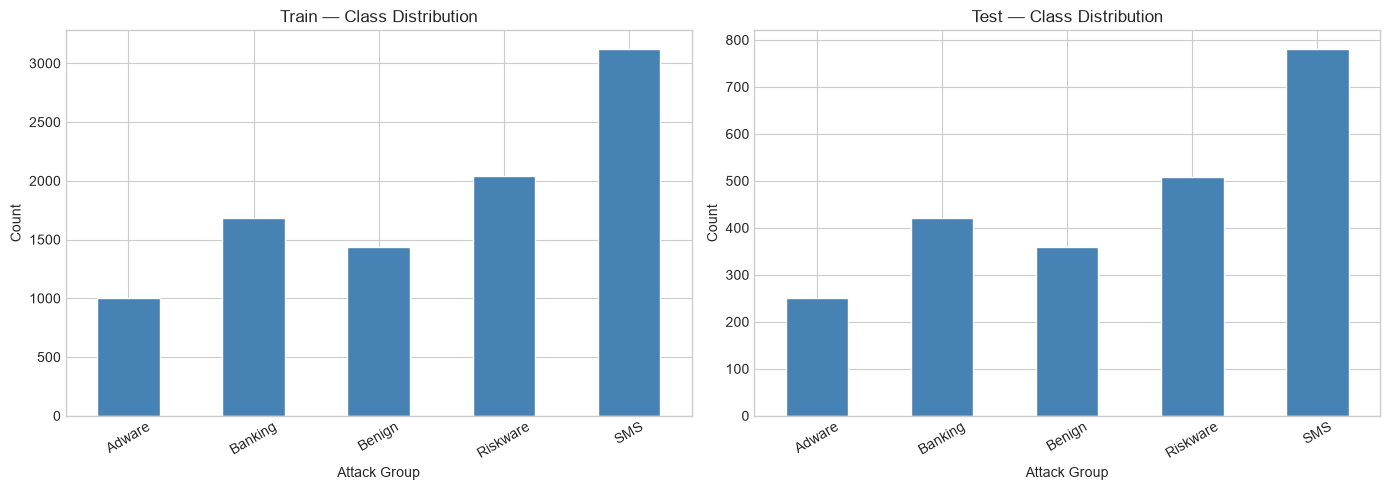

Train class counts:
Class_encoded
SMS         3123
Riskware    2037
Banking     1680
Benign      1436
Adware      1002
Name: count, dtype: int64
Test class counts:
Class_encoded
SMS         781
Riskware    509
Banking     420
Benign      359
Adware      251
Name: count, dtype: int64


In [13]:
# --- 5a. Class distribution ---
label_names = dict(enumerate(le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (y, title) in zip(axes, [(y_train, "Train"), (y_test, "Test")]):
    counts = y.value_counts().sort_index()
    counts.index = [label_names[i] for i in counts.index]
    counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"{title} — Class Distribution")
    ax.set_xlabel("Attack Group")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print("Train class counts:")
print(y_train.map(label_names).value_counts())
print("Test class counts:")
print(y_test.map(label_names).value_counts())


Top 30 features by Information Gain (Mutual Information):
['sendto', 'lseek', 'hasNavigationBar', 'prctl', 'addClient', 'sigaction', 'gettimeofday', 'fcntl64', 'DEVICE_ACCESS_____', 'getProxy', 'setrlimit', 'setresgid32', 'registerCallback', 'FS_ACCESS(WRITE)____', 'setresuid32', 'setgroups32', 'capset', 'getPackagesForUid', 'flock', 'uname', 'getDisplayInfo', 'getPackageInfo', 'FS_ACCESS(CREATE)____', 'NETWORK_ACCESS(WRITE)____', 'CREATE_FOLDER_____', 'pipe', 'FS_PIPE_ACCESS___', 'FS_ACCESS____', '_llseek', 'pread64']


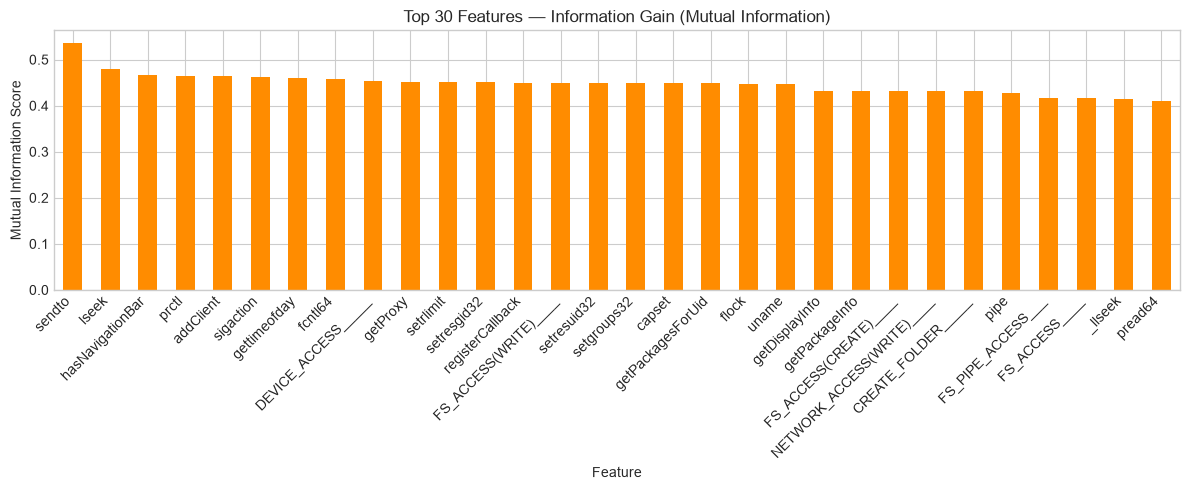

In [8]:
from sklearn.feature_selection import mutual_info_classif
X_train=X_train_p
k_mi = 30   

mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_scores_series = pd.Series(mi_scores, index=X_train.columns)
mi_scores_sorted = mi_scores_series.sort_values(ascending=False)

selected_features_mi = mi_scores_sorted.head(k_mi).index.tolist()
print(f"Top {k_mi} features by Information Gain (Mutual Information):")
print(selected_features_mi)

# Plot
plt.figure(figsize=(12, 5))
mi_scores_sorted.head(k_mi).plot(kind='bar', color='darkorange', edgecolor='none')
plt.title(f'Top {k_mi} Features — Information Gain (Mutual Information)')
plt.xlabel('Feature')
plt.ylabel('Mutual Information Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Top 30 features selected by Chi-Square test:
['read', 'prctl', 'fcntl64', 'sigprocmask', 'gettimeofday', 'sendto', 'clock_gettime', 'pwrite64', 'writev', 'recvfrom', 'fstat64', 'mmap2', 'ioctl', 'close', '__arm_nr_cacheflush', 'inotify_add_watch', 'epoll_wait', 'fdatasync', 'madvise', 'nanosleep', 'getLine1Number', 'fchown32', 'munmap', 'mprotect', 'lstat64', 'open', 'futex', 'pread64', 'write', 'gettid']


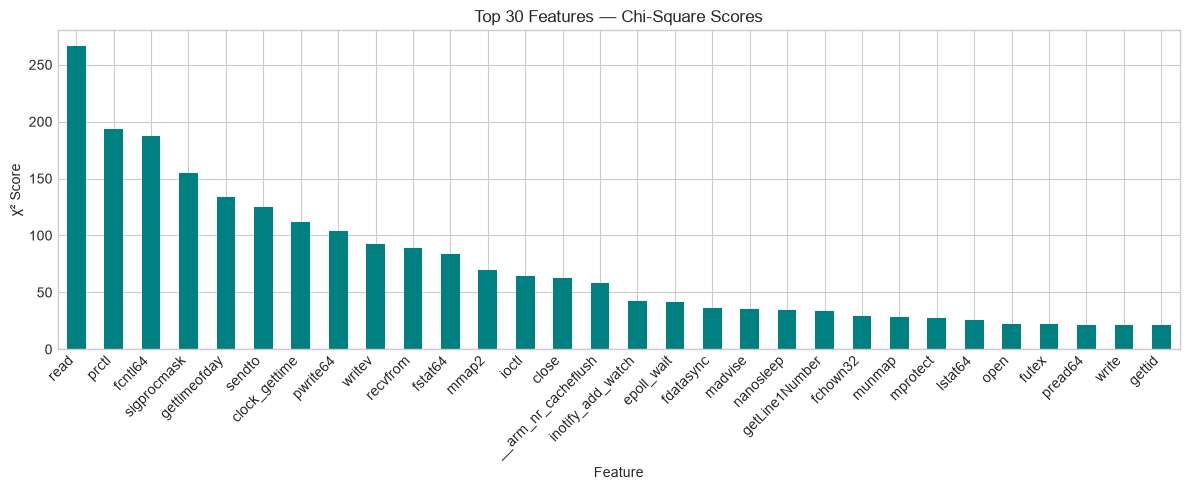

In [14]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

X_train=X_train_p
X_test=X_test_p

k = 30  

chi2_selector = SelectKBest(score_func=chi2, k=k)
chi2_selector.fit(X_train, y_train)

chi2_scores = pd.Series(chi2_selector.scores_, index=X_train.columns)
chi2_scores_sorted = chi2_scores.sort_values(ascending=False)

selected_features_chi2 = chi2_scores_sorted.head(k).index.tolist()
print(f"Top {k} features selected by Chi-Square test:")
print(selected_features_chi2)

# Plot top-k chi2 scores
plt.figure(figsize=(12, 5))
chi2_scores_sorted.head(k).plot(kind='bar', color='teal', edgecolor='none')
plt.title(f'Top {k} Features — Chi-Square Scores')
plt.xlabel('Feature')
plt.ylabel('χ² Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

 Running RFECV (Recursive Feature Elimination with Cross-Validation) using XGBoost

 Optimal number of features found by RFECV: 190
Selected Features: ['ACCESS_PERSONAL_INFO___', 'CREATE_FOLDER_____', 'CREATE_PROCESS`_____', 'CREATE_THREAD_____', 'DEVICE_ACCESS_____', 'EXECUTE_____', 'FS_ACCESS____', 'FS_ACCESS()____', 'FS_ACCESS(CREATE)____', 'FS_ACCESS(CREATE__APPEND)__', 'FS_ACCESS(CREATE__READ)__', 'FS_ACCESS(CREATE__READ__WRITE)', 'FS_ACCESS(CREATE__WRITE)__', 'FS_ACCESS(CREATE__WRITE__APPEND)', 'FS_ACCESS(READ)____', 'FS_PIPE_ACCESS___', 'FS_PIPE_ACCESS(READ)___', 'FS_PIPE_ACCESS(READ__)_', 'FS_PIPE_ACCESS(READ__WRITE)_', 'FS_PIPE_ACCESS(WRITE)___', 'NETWORK_ACCESS____', 'NETWORK_ACCESS()____', 'NETWORK_ACCESS(READ__WRITE)__', 'NETWORK_ACCESS(WRITE)____', 'NETWORK_ACCESS(WRITE__)__', 'SMS_SEND____', 'TERMINATE_PROCESS', 'TERMINATE_THREAD', '__arm_nr_cacheflush', '_llseek', '_newselect', 'access', 'addAccessibilityInteractionConnection', 'addClient', 'addToDisplay', 'addToDisplayW

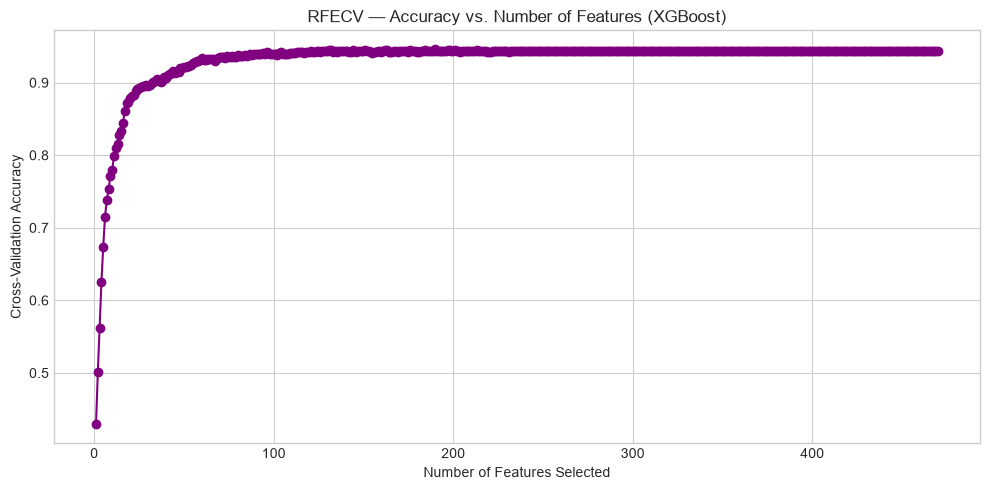


 RFECV Completed and data saved successfully!


In [10]:
import matplotlib.pyplot as plt
from xgboost import XGBClassifier  
from sklearn.feature_selection import RFECV
import joblib


estimator = XGBClassifier(random_state=42, n_jobs=1)

print(" Running RFECV (Recursive Feature Elimination with Cross-Validation) using XGBoost")
rfecv = RFECV(
    estimator=estimator,
    step=1,          
    cv=5,            
    scoring='accuracy',
    n_jobs=-1        
)

rfecv.fit(X_train_p, y_train)

print(f"\n Optimal number of features found by RFECV: {rfecv.n_features_}")

selected_features_rfecv = X_train_p.columns[rfecv.support_].tolist()
print(f"Selected Features: {selected_features_rfecv}")

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'], color='purple', marker='o')
plt.xlabel("Number of Features Selected")
plt.ylabel("Cross-Validation Accuracy")
plt.title("RFECV — Accuracy vs. Number of Features (XGBoost)")
plt.grid(True)
plt.tight_layout()
plt.show()

X_train_rfecv = rfecv.transform(X_train_p)
X_test_rfecv  = rfecv.transform(X_test_p)

joblib.dump(X_train_rfecv, "X_train_rfecv_cic.pkl")
joblib.dump(X_test_rfecv, "X_test_rfecv_cic.pkl")
print("\n RFECV Completed and data saved successfully!")

In [15]:
import matplotlib.pyplot as plt
from xgboost import XGBClassifier 
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

6

estimator = XGBClassifier(random_state=42, n_jobs=1)

print(" Running Forward Selection ")
forward_selector = SFS(
    estimator=estimator,
    k_features=20,       
    forward=True,        
    floating=False,
    scoring='accuracy',
    cv=5,                
    n_jobs=-1            
)

forward_selector.fit(X_train_p, y_train)

selected_features_forward = list(forward_selector.k_feature_names_)
print(f"\n Top 20 features selected by Forward Selection:")
print(selected_features_forward)

X_train_fwd = forward_selector.transform(X_train_p) 
X_test_fwd  = forward_selector.transform(X_test_p)

joblib.dump(X_train_fwd, "X_train_forward_cic.pkl")
joblib.dump(X_test_fwd, "X_test_forward_cic.pkl")
print("\n Forward Selection Completed and data saved successfully!")

 Running Forward Selection 

 Top 20 features selected by Forward Selection:
['ACCESS_PERSONAL_INFO___', 'access', 'chmod', 'epoll_wait', 'ftruncate', 'getAllNetworkInfo', 'getApplicationInfo', 'getConnectionInfo', 'getDeviceId', 'getDisplayInfo', 'getInstallerPackageName', 'lseek', 'mmap2', 'mprotect', 'rt_sigprocmask', 'sendto', 'showSoftInput', 'sigprocmask', 'socket', 'windowGainedFocus']

 Forward Selection Completed and data saved successfully!


In [16]:


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

all_classes = le.transform(le.classes_)
CLASS_NAMES = list(le.classes_)

def evaluate(name, y_true, y_pred):
    
    acc     = accuracy_score(y_true, y_pred)
    prec    = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec     = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1      = f1_score(y_true, y_pred, average='weighted')
    f1_mac  = f1_score(y_true, y_pred, average='macro')

    print(f'\n=== {name} ===')
    print(f'Accuracy : {acc:.4f}   Precision : {prec:.4f}   Recall : {rec:.4f}   '
          f'Weighted F1 : {f1:.4f}   Macro F1: {f1_mac:.4f}')

    print(classification_report(y_true, y_pred, labels=all_classes, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred, labels=all_classes)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.tight_layout()
    plt.show()

    return acc, prec, rec, f1, f1_mac

RESULTS = {}

 Starting SVM Evaluation across ALL Feature Selection methods...

 Testing Feature Set: Full_Features (Features Count: 470)

 Linear SVM Training Time: 1.25 seconds
 Predict Time  : 0.0183 seconds

=== SVM (Linear) — Full_Features ===
Accuracy : 0.6875   Precision : 0.6898   Recall : 0.6875   Weighted F1 : 0.6751   Macro F1: 0.6389
              precision    recall  f1-score   support

      Adware       0.74      0.36      0.48       251
     Banking       0.72      0.55      0.62       420
      Benign       0.63      0.66      0.64       359
    Riskware       0.66      0.64      0.65       509
         SMS       0.71      0.91      0.80       781

    accuracy                           0.69      2320
   macro avg       0.69      0.62      0.64      2320
weighted avg       0.69      0.69      0.68      2320



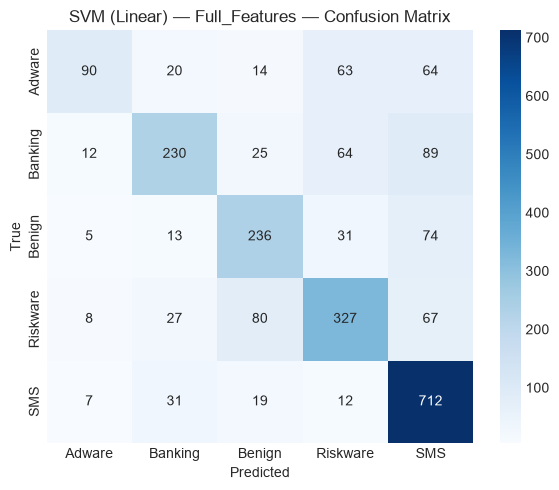


 RBF SVM Training Time: 6.85 seconds
 Predict Time  : 2.0623 seconds

=== SVM (RBF) — Full_Features ===
Accuracy : 0.8366   Precision : 0.8361   Recall : 0.8366   Weighted F1 : 0.8346   Macro F1: 0.8105
              precision    recall  f1-score   support

      Adware       0.72      0.69      0.70       251
     Banking       0.89      0.79      0.84       420
      Benign       0.81      0.75      0.78       359
    Riskware       0.84      0.82      0.83       509
         SMS       0.86      0.96      0.90       781

    accuracy                           0.84      2320
   macro avg       0.82      0.80      0.81      2320
weighted avg       0.84      0.84      0.83      2320



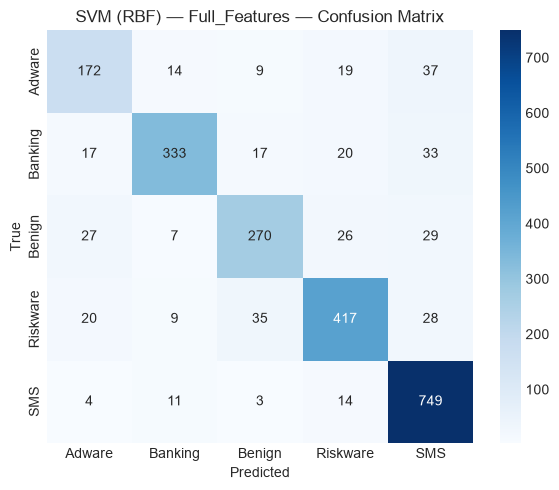

 Testing Feature Set: Filter_MI (Features Count: 30)

 Linear SVM Training Time: 0.21 seconds
 Predict Time  : 0.0020 seconds

=== SVM (Linear) — Filter_MI ===
Accuracy : 0.5207   Precision : 0.5651   Recall : 0.5207   Weighted F1 : 0.4414   Macro F1: 0.3659
              precision    recall  f1-score   support

      Adware       0.56      0.06      0.10       251
     Banking       0.72      0.11      0.20       420
      Benign       0.59      0.20      0.30       359
    Riskware       0.51      0.63      0.56       509
         SMS       0.51      0.96      0.67       781

    accuracy                           0.52      2320
   macro avg       0.58      0.39      0.37      2320
weighted avg       0.57      0.52      0.44      2320



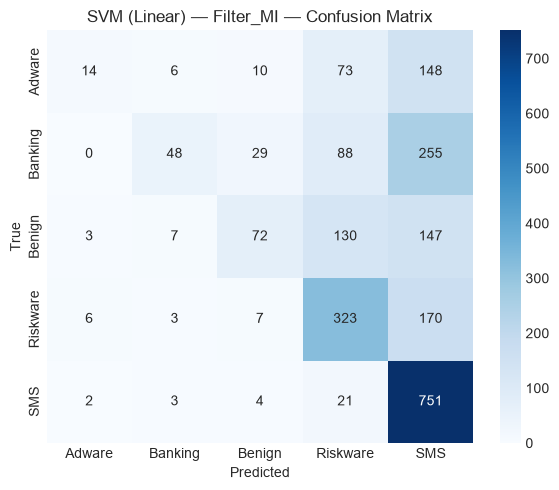


 RBF SVM Training Time: 2.27 seconds
 Predict Time  : 0.8486 seconds

=== SVM (RBF) — Filter_MI ===
Accuracy : 0.7121   Precision : 0.7060   Recall : 0.7121   Weighted F1 : 0.7005   Macro F1: 0.6611
              precision    recall  f1-score   support

      Adware       0.62      0.48      0.54       251
     Banking       0.70      0.50      0.58       420
      Benign       0.63      0.58      0.60       359
    Riskware       0.75      0.75      0.75       509
         SMS       0.74      0.94      0.83       781

    accuracy                           0.71      2320
   macro avg       0.69      0.65      0.66      2320
weighted avg       0.71      0.71      0.70      2320



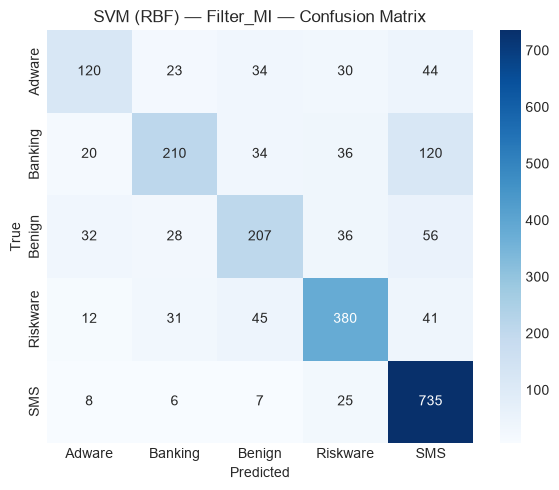

 Testing Feature Set: Filter_Chi2 (Features Count: 30)

 Linear SVM Training Time: 0.27 seconds
 Predict Time  : 0.0024 seconds

=== SVM (Linear) — Filter_Chi2 ===
Accuracy : 0.6444   Precision : 0.6417   Recall : 0.6444   Weighted F1 : 0.6260   Macro F1: 0.5766
              precision    recall  f1-score   support

      Adware       0.59      0.26      0.36       251
     Banking       0.68      0.43      0.53       420
      Benign       0.54      0.62      0.58       359
    Riskware       0.63      0.64      0.63       509
         SMS       0.69      0.90      0.78       781

    accuracy                           0.64      2320
   macro avg       0.63      0.57      0.58      2320
weighted avg       0.64      0.64      0.63      2320



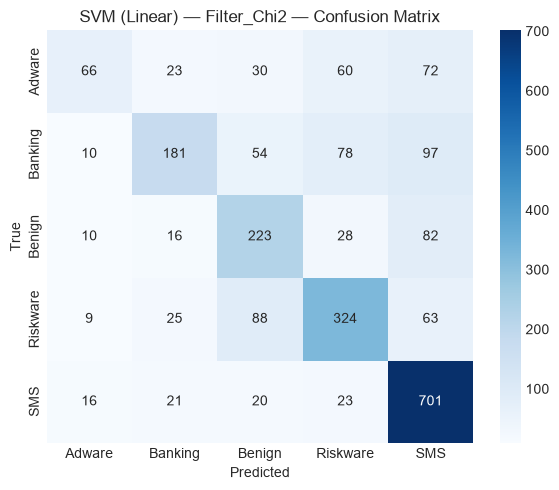


 RBF SVM Training Time: 1.17 seconds
 Predict Time  : 0.5056 seconds

=== SVM (RBF) — Filter_Chi2 ===
Accuracy : 0.8293   Precision : 0.8297   Recall : 0.8293   Weighted F1 : 0.8275   Macro F1: 0.8001
              precision    recall  f1-score   support

      Adware       0.68      0.67      0.68       251
     Banking       0.90      0.77      0.83       420
      Benign       0.78      0.74      0.76       359
    Riskware       0.84      0.82      0.83       509
         SMS       0.86      0.96      0.90       781

    accuracy                           0.83      2320
   macro avg       0.81      0.79      0.80      2320
weighted avg       0.83      0.83      0.83      2320



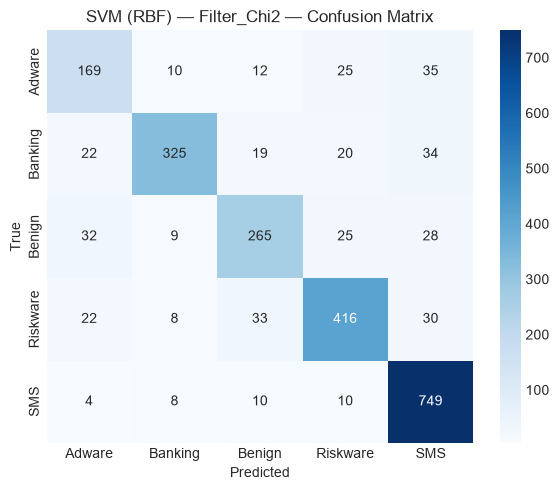

 Testing Feature Set: Wrapper_RFECV (Features Count: 190)

 Linear SVM Training Time: 0.64 seconds
 Predict Time  : 0.0011 seconds

=== SVM (Linear) — Wrapper_RFECV ===
Accuracy : 0.6853   Precision : 0.6879   Recall : 0.6853   Weighted F1 : 0.6719   Macro F1: 0.6345
              precision    recall  f1-score   support

      Adware       0.71      0.35      0.47       251
     Banking       0.74      0.52      0.61       420
      Benign       0.64      0.65      0.64       359
    Riskware       0.65      0.65      0.65       509
         SMS       0.70      0.92      0.79       781

    accuracy                           0.69      2320
   macro avg       0.69      0.62      0.63      2320
weighted avg       0.69      0.69      0.67      2320



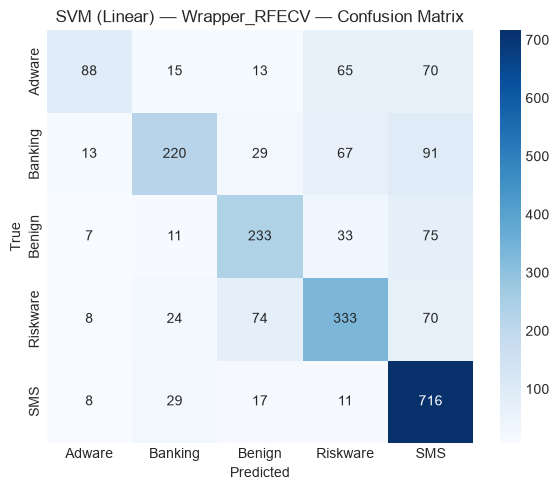


 RBF SVM Training Time: 3.29 seconds
 Predict Time  : 1.2053 seconds

=== SVM (RBF) — Wrapper_RFECV ===
Accuracy : 0.8336   Precision : 0.8333   Recall : 0.8336   Weighted F1 : 0.8315   Macro F1: 0.8071
              precision    recall  f1-score   support

      Adware       0.71      0.67      0.69       251
     Banking       0.90      0.80      0.85       420
      Benign       0.81      0.74      0.77       359
    Riskware       0.83      0.83      0.83       509
         SMS       0.85      0.95      0.90       781

    accuracy                           0.83      2320
   macro avg       0.82      0.80      0.81      2320
weighted avg       0.83      0.83      0.83      2320



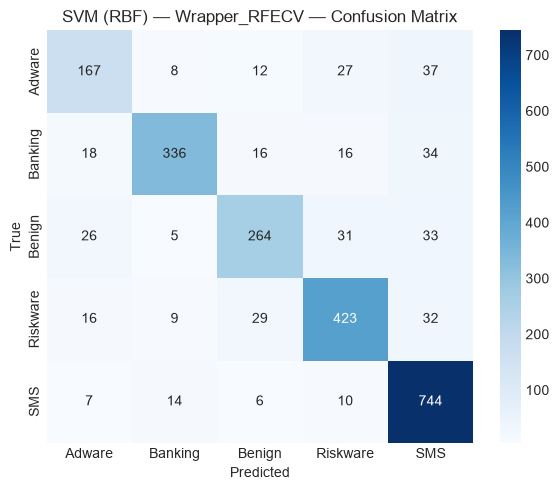

 Testing Feature Set: Wrapper_Forward (Features Count: 20)

 Linear SVM Training Time: 0.12 seconds
 Predict Time  : 0.0009 seconds

=== SVM (Linear) — Wrapper_Forward ===
Accuracy : 0.5198   Precision : 0.5607   Recall : 0.5198   Weighted F1 : 0.4539   Macro F1: 0.3765
              precision    recall  f1-score   support

      Adware       1.00      0.00      0.01       251
     Banking       0.25      0.13      0.17       420
      Benign       0.76      0.38      0.51       359
    Riskware       0.49      0.52      0.50       509
         SMS       0.54      0.96      0.69       781

    accuracy                           0.52      2320
   macro avg       0.61      0.40      0.38      2320
weighted avg       0.56      0.52      0.45      2320



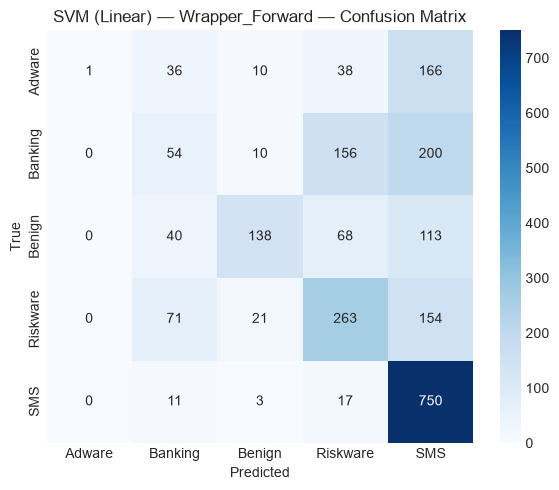


 RBF SVM Training Time: 2.16 seconds
 Predict Time  : 0.8178 seconds

=== SVM (RBF) — Wrapper_Forward ===
Accuracy : 0.7228   Precision : 0.7228   Recall : 0.7228   Weighted F1 : 0.7170   Macro F1: 0.6796
              precision    recall  f1-score   support

      Adware       0.64      0.50      0.56       251
     Banking       0.76      0.62      0.68       420
      Benign       0.57      0.65      0.61       359
    Riskware       0.75      0.64      0.69       509
         SMS       0.78      0.93      0.85       781

    accuracy                           0.72      2320
   macro avg       0.70      0.67      0.68      2320
weighted avg       0.72      0.72      0.72      2320



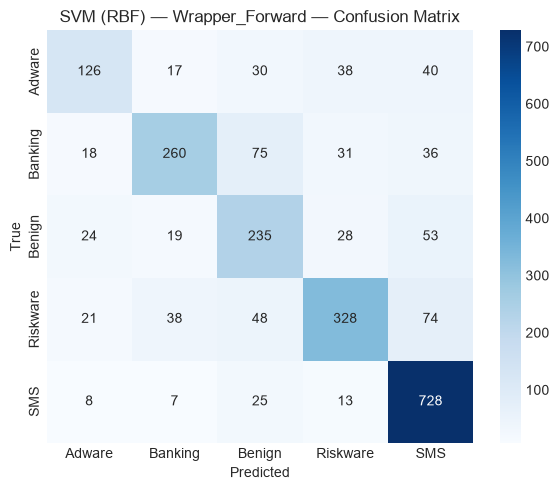


 All SVM models trained and evaluated successfully!


In [17]:
from sklearn.svm import SVC, LinearSVC
from sklearn.pipeline import Pipeline
import time


def _make_linear_svc():
    return Pipeline([
        ('clf', LinearSVC(C=1.0, max_iter=2000 , random_state=42)),
    ])

def _make_rbf_svc():
    return Pipeline([
        ('clf', SVC(kernel='rbf', C=10, gamma='scale',
                    decision_function_shape='ovr', random_state=42)),
    ])

FEATURE_SETS = {
    'Full_Features': (X_train_p, X_test_p),
    'Filter_MI': (X_train_p[selected_features_mi], X_test_p[selected_features_mi]),
    'Filter_Chi2': (X_train_p[selected_features_chi2], X_test_p[selected_features_chi2]),
    'Wrapper_RFECV': (X_train_rfecv, X_test_rfecv),
    'Wrapper_Forward': (X_train_fwd, X_test_fwd)
}

print(" Starting SVM Evaluation across ALL Feature Selection methods...\n")

for fs_name, (X_tr, X_te) in FEATURE_SETS.items():
    print(f"{'='*60}")
    print(f" Testing Feature Set: {fs_name} (Features Count: {X_tr.shape[1]})")
    print(f"{'='*60}")
    
    for kind, factory in [('Linear', _make_linear_svc), ('RBF', _make_rbf_svc)]:
        clf = factory()
        
        start_time = time.time()
        clf.fit(X_tr, y_train)
        train_time = time.time() - start_time
        start_pred = time.time()
        
        y_pred = clf.predict(X_te)
        pred_time = time.time() - start_pred
        
        label = f'SVM ({kind}) — {fs_name}'
        print(f"\n {kind} SVM Training Time: {train_time:.2f} seconds")
        print(f" Predict Time  : {pred_time:.4f} seconds")
        acc, prec, rec, f1, macro = evaluate(label, y_test, y_pred)

        
        RESULTS[label] =  {'Accuracy': acc,'Weighted F1': f1,'Macro F1': macro,'Train Time (s)': train_time,    'Predict Time (s)': pred_time    
                }

print("\n All SVM models trained and evaluated successfully!")

 Starting MLP Evaluation across ALL Feature Selection methods

Testing Feature Set: Full_Features (Features Count: 470)
Iteration 1, loss = 1.52954646
Validation score: 0.390086
Iteration 2, loss = 1.35408679
Validation score: 0.519397
Iteration 3, loss = 1.16722896
Validation score: 0.609914
Iteration 4, loss = 1.04142706
Validation score: 0.672414
Iteration 5, loss = 0.95665114
Validation score: 0.701509
Iteration 6, loss = 0.88669181
Validation score: 0.700431
Iteration 7, loss = 0.82553255
Validation score: 0.727371
Iteration 8, loss = 0.77190646
Validation score: 0.743534
Iteration 9, loss = 0.73168675
Validation score: 0.756466
Iteration 10, loss = 0.69268682
Validation score: 0.765086
Iteration 11, loss = 0.66451576
Validation score: 0.771552
Iteration 12, loss = 0.64111463
Validation score: 0.794181
Iteration 13, loss = 0.61692309
Validation score: 0.794181
Iteration 14, loss = 0.59881384
Validation score: 0.796336
Iteration 15, loss = 0.58442852
Validation score: 0.806034
Iter

C:\Users\ASUS TUF\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


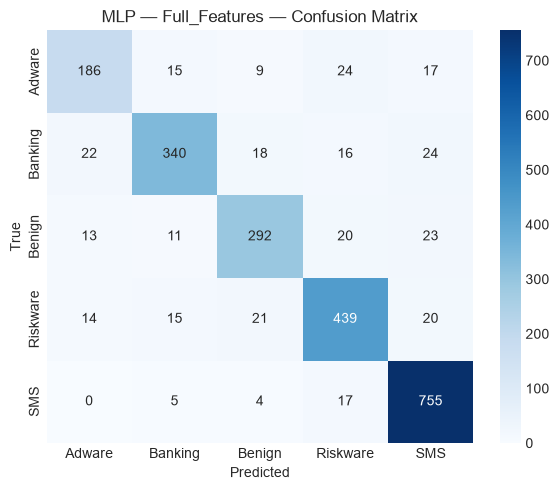

Testing Feature Set: Filter_MI (Features Count: 30)

 MLP Training Time: 3.37 seconds

 MLP predict Time: 0.00 seconds

=== MLP — Filter_MI ===
Accuracy : 0.6918   Precision : 0.6818   Recall : 0.6918   Weighted F1 : 0.6781   Macro F1: 0.6253
              precision    recall  f1-score   support

      Adware       0.56      0.31      0.40       251
     Banking       0.64      0.55      0.59       420
      Benign       0.68      0.54      0.60       359
    Riskware       0.63      0.77      0.70       509
         SMS       0.78      0.91      0.84       781

    accuracy                           0.69      2320
   macro avg       0.66      0.62      0.63      2320
weighted avg       0.68      0.69      0.68      2320



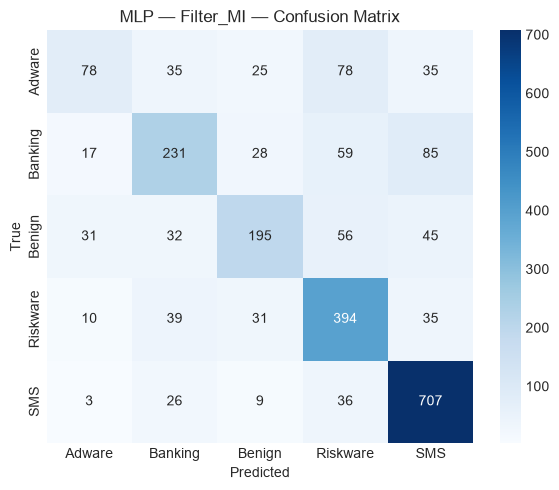

Testing Feature Set: Filter_Chi2 (Features Count: 30)

 MLP Training Time: 2.29 seconds

 MLP predict Time: 0.01 seconds

=== MLP — Filter_Chi2 ===
Accuracy : 0.7793   Precision : 0.7762   Recall : 0.7793   Weighted F1 : 0.7718   Macro F1: 0.7310
              precision    recall  f1-score   support

      Adware       0.61      0.44      0.51       251
     Banking       0.86      0.72      0.78       420
      Benign       0.78      0.65      0.71       359
    Riskware       0.73      0.82      0.77       509
         SMS       0.81      0.95      0.88       781

    accuracy                           0.78      2320
   macro avg       0.76      0.72      0.73      2320
weighted avg       0.78      0.78      0.77      2320



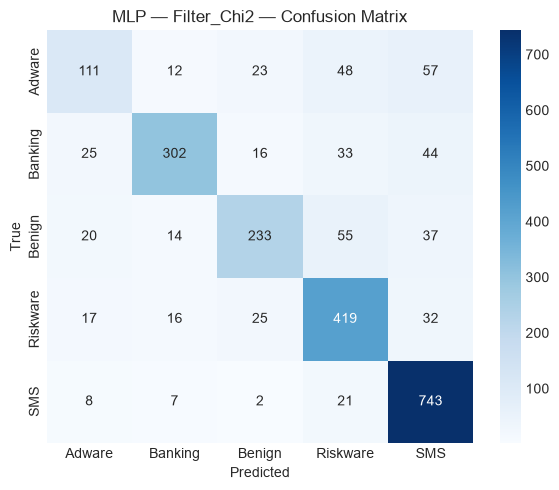

Testing Feature Set: Wrapper_RFECV (Features Count: 190)


C:\Users\ASUS TUF\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(



 MLP Training Time: 4.86 seconds

 MLP predict Time: 0.00 seconds

=== MLP — Wrapper_RFECV ===
Accuracy : 0.8565   Precision : 0.8586   Recall : 0.8565   Weighted F1 : 0.8558   Macro F1: 0.8337
              precision    recall  f1-score   support

      Adware       0.72      0.78      0.75       251
     Banking       0.93      0.80      0.86       420
      Benign       0.79      0.80      0.80       359
    Riskware       0.87      0.81      0.84       509
         SMS       0.89      0.97      0.93       781

    accuracy                           0.86      2320
   macro avg       0.84      0.83      0.83      2320
weighted avg       0.86      0.86      0.86      2320



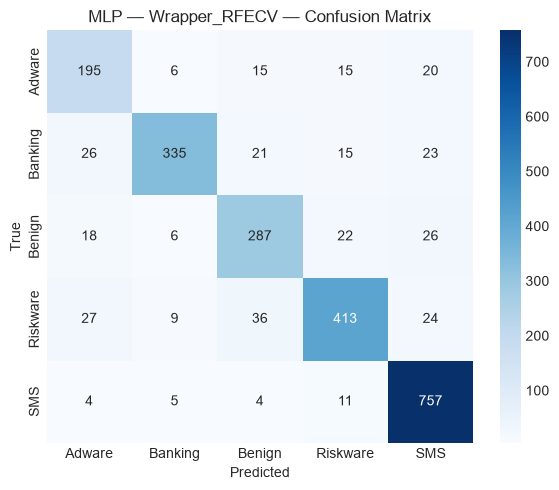

Testing Feature Set: Wrapper_Forward (Features Count: 20)

 MLP Training Time: 2.75 seconds

 MLP predict Time: 0.00 seconds

=== MLP — Wrapper_Forward ===
Accuracy : 0.6595   Precision : 0.6480   Recall : 0.6595   Weighted F1 : 0.6471   Macro F1: 0.5996
              precision    recall  f1-score   support

      Adware       0.49      0.42      0.45       251
     Banking       0.61      0.45      0.51       420
      Benign       0.66      0.54      0.59       359
    Riskware       0.59      0.62      0.60       509
         SMS       0.76      0.93      0.83       781

    accuracy                           0.66      2320
   macro avg       0.62      0.59      0.60      2320
weighted avg       0.65      0.66      0.65      2320



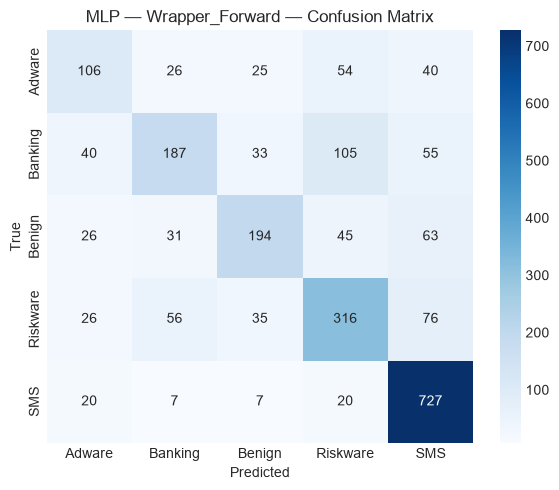


 All MLP models trained and evaluated successfully


In [18]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
import time

def _make_mlp(verbose=False):
    return Pipeline([
        ('clf', MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation='relu', solver='adam',
            alpha=1e-4, batch_size=256,
            learning_rate_init=1e-3, max_iter=50,
            early_stopping=True, validation_fraction=0.1,
            n_iter_no_change=5, random_state=42, verbose=verbose)),
    ])

print(" Starting MLP Evaluation across ALL Feature Selection methods\n")

for fs_name, (X_tr, X_te) in FEATURE_SETS.items():
    print(f"{'='*60}")
    print(f"Testing Feature Set: {fs_name} (Features Count: {X_tr.shape[1]})")
    print(f"{'='*60}")
    
    is_baseline = (fs_name == 'Full_Features')
    mlp_pipeline = _make_mlp(verbose=is_baseline)
    
    
    start_time = time.time()
    mlp_pipeline.fit(X_tr, y_train)
    train_time = time.time() - start_time
    start_pred = time.time()   
    y_pred = mlp_pipeline.predict(X_te)
    pred_time = time.time() - start_pred
    label = f'MLP — {fs_name}'
    print(f"\n MLP Training Time: {train_time:.2f} seconds")
    print(f"\n MLP predict Time: {pred_time:.2f} seconds")

    
    acc, prec, rec, f1, macro = evaluate(label, y_test, y_pred)
    
   
    RESULTS[label] =  {'Accuracy': acc,'Weighted F1': f1,'Macro F1': macro,'Train Time (s)': train_time,    'Predict Time (s)': pred_time    
                }

print("\n All MLP models trained and evaluated successfully")

 Starting XGBoost Baseline (Without GridSearchCV) across ALL Feature Sets...

 Testing XGBoost Baseline on Feature Set: Full_Features (Features Count: 470)

 Training Time: 5.09 seconds

 predict Time: 0.05 seconds

=== XGBoost (Baseline) — Full_Features ===
Accuracy : 0.9409   Precision : 0.9409   Recall : 0.9409   Weighted F1 : 0.9408   Macro F1: 0.9317
              precision    recall  f1-score   support

      Adware       0.91      0.91      0.91       251
     Banking       0.95      0.91      0.93       420
      Benign       0.91      0.92      0.92       359
    Riskware       0.92      0.92      0.92       509
         SMS       0.97      0.99      0.98       781

    accuracy                           0.94      2320
   macro avg       0.93      0.93      0.93      2320
weighted avg       0.94      0.94      0.94      2320



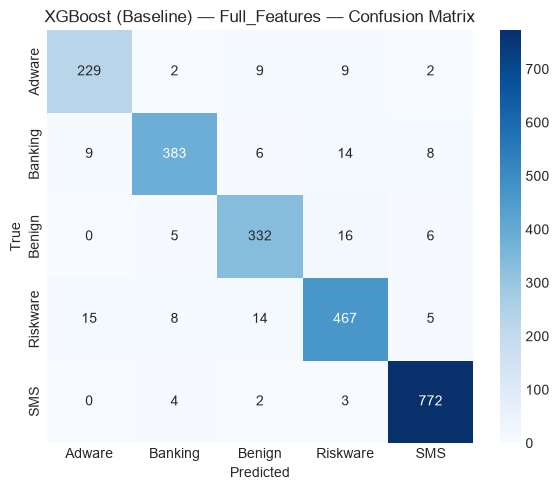

 Testing XGBoost Baseline on Feature Set: Filter_MI (Features Count: 30)

 Training Time: 0.76 seconds

 predict Time: 0.01 seconds

=== XGBoost (Baseline) — Filter_MI ===
Accuracy : 0.8987   Precision : 0.8983   Recall : 0.8987   Weighted F1 : 0.8984   Macro F1: 0.8774
              precision    recall  f1-score   support

      Adware       0.82      0.82      0.82       251
     Banking       0.89      0.87      0.88       420
      Benign       0.82      0.82      0.82       359
    Riskware       0.90      0.88      0.89       509
         SMS       0.96      0.98      0.97       781

    accuracy                           0.90      2320
   macro avg       0.88      0.88      0.88      2320
weighted avg       0.90      0.90      0.90      2320



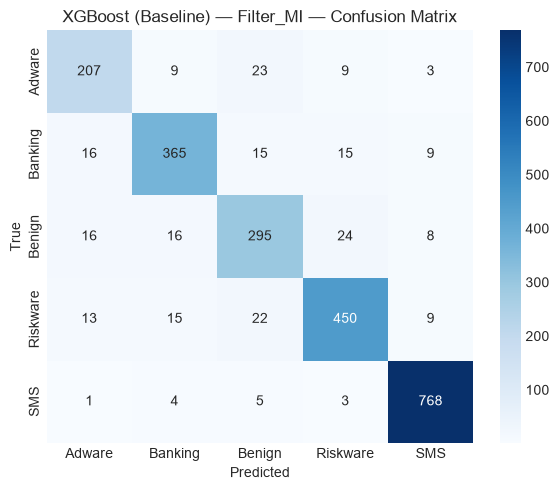

 Testing XGBoost Baseline on Feature Set: Filter_Chi2 (Features Count: 30)

 Training Time: 0.72 seconds

 predict Time: 0.01 seconds

=== XGBoost (Baseline) — Filter_Chi2 ===
Accuracy : 0.9039   Precision : 0.9038   Recall : 0.9039   Weighted F1 : 0.9038   Macro F1: 0.8820
              precision    recall  f1-score   support

      Adware       0.79      0.80      0.80       251
     Banking       0.91      0.89      0.90       420
      Benign       0.84      0.85      0.84       359
    Riskware       0.90      0.89      0.89       509
         SMS       0.97      0.98      0.97       781

    accuracy                           0.90      2320
   macro avg       0.88      0.88      0.88      2320
weighted avg       0.90      0.90      0.90      2320



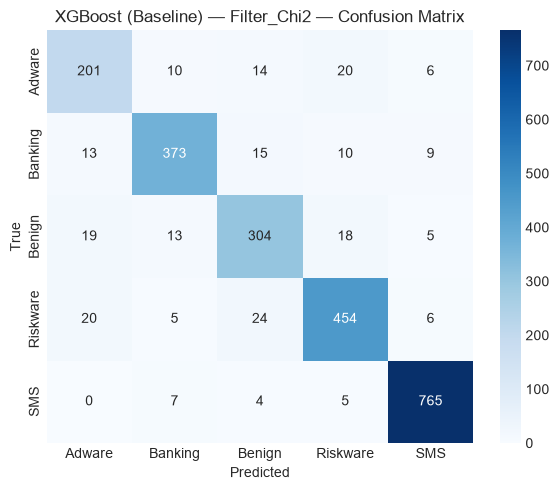

 Testing XGBoost Baseline on Feature Set: Wrapper_RFECV (Features Count: 190)

 Training Time: 2.91 seconds

 predict Time: 0.00 seconds

=== XGBoost (Baseline) — Wrapper_RFECV ===
Accuracy : 0.9405   Precision : 0.9407   Recall : 0.9405   Weighted F1 : 0.9405   Macro F1: 0.9304
              precision    recall  f1-score   support

      Adware       0.89      0.91      0.90       251
     Banking       0.95      0.90      0.93       420
      Benign       0.91      0.93      0.92       359
    Riskware       0.92      0.92      0.92       509
         SMS       0.98      0.99      0.98       781

    accuracy                           0.94      2320
   macro avg       0.93      0.93      0.93      2320
weighted avg       0.94      0.94      0.94      2320



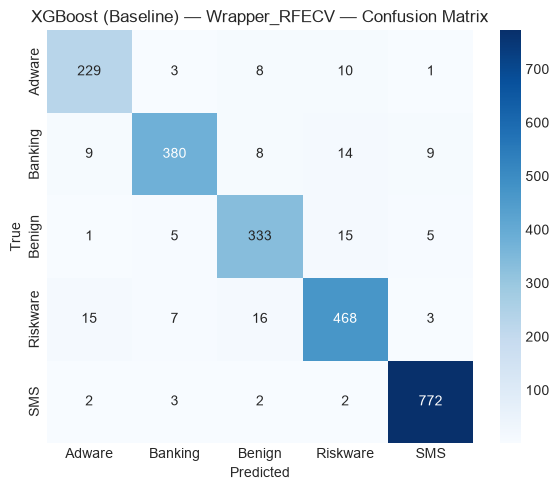

 Testing XGBoost Baseline on Feature Set: Wrapper_Forward (Features Count: 20)

 Training Time: 0.47 seconds

 predict Time: 0.00 seconds

=== XGBoost (Baseline) — Wrapper_Forward ===
Accuracy : 0.9190   Precision : 0.9188   Recall : 0.9190   Weighted F1 : 0.9188   Macro F1: 0.9032
              precision    recall  f1-score   support

      Adware       0.85      0.86      0.85       251
     Banking       0.92      0.89      0.90       420
      Benign       0.88      0.88      0.88       359
    Riskware       0.91      0.90      0.90       509
         SMS       0.97      0.98      0.98       781

    accuracy                           0.92      2320
   macro avg       0.90      0.90      0.90      2320
weighted avg       0.92      0.92      0.92      2320



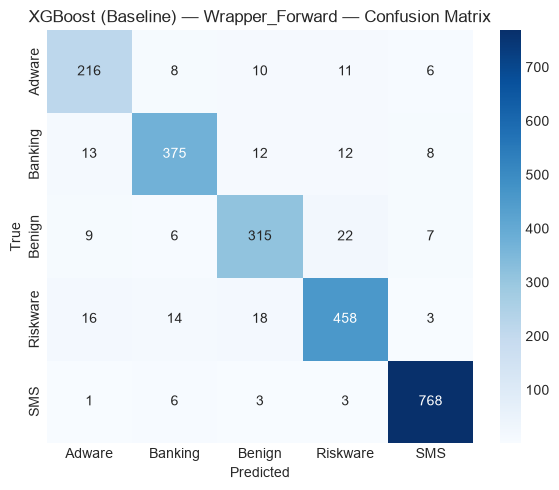


 All XGBoost baseline models evaluated successfully!


In [19]:
import xgboost as xgb
import time

print(" Starting XGBoost Baseline (Without GridSearchCV) across ALL Feature Sets...\n")


for fs_name, (X_tr, X_te) in FEATURE_SETS.items():
    print(f"{'='*60}")
    print(f" Testing XGBoost Baseline on Feature Set: {fs_name} (Features Count: {X_tr.shape[1]})")
    print(f"{'='*60}")
    
    
    xgb_baseline = xgb.XGBClassifier(verbosity=0, random_state=42, n_jobs=-1)
    
    start_time = time.time()
    xgb_baseline.fit(X_tr, y_train)
    train_time = time.time() - start_time
    start_pred = time.time()   
    y_pred = xgb_baseline.predict(X_te)
    pred_time = time.time() - start_pred
    
    label = f'XGBoost (Baseline) — {fs_name}'
    print(f"\n Training Time: {train_time:.2f} seconds")
    print(f"\n predict Time: {pred_time:.2f} seconds")

 
    acc, prec, rec, f1, macro = evaluate(label, y_test, y_pred)
    RESULTS[label] =  {'Accuracy': acc,'Weighted F1': f1,'Macro F1': macro,'Train Time (s)': train_time,    'Predict Time (s)': pred_time    
                }

print("\n All XGBoost baseline models evaluated successfully!")

 Starting SVM + GridSearchCV Evaluation ON SELECTED FEATURES ONLY...

 Testing SVM (GridSearchCV) on Feature Set: Filter_MI
 Training Time: 66.60s |  Best Params: {'clf__C': 1000, 'clf__gamma': 1, 'clf__kernel': 'rbf'}

 predict Time: 0.84 seconds

=== SVM (Optimized) — Filter_MI ===
Accuracy : 0.7138   Precision : 0.7150   Recall : 0.7138   Weighted F1 : 0.7030   Macro F1: 0.6708
              precision    recall  f1-score   support

      Adware       0.65      0.54      0.59       251
     Banking       0.77      0.49      0.59       420
      Benign       0.64      0.60      0.62       359
    Riskware       0.75      0.72      0.73       509
         SMS       0.72      0.94      0.82       781

    accuracy                           0.71      2320
   macro avg       0.71      0.66      0.67      2320
weighted avg       0.72      0.71      0.70      2320



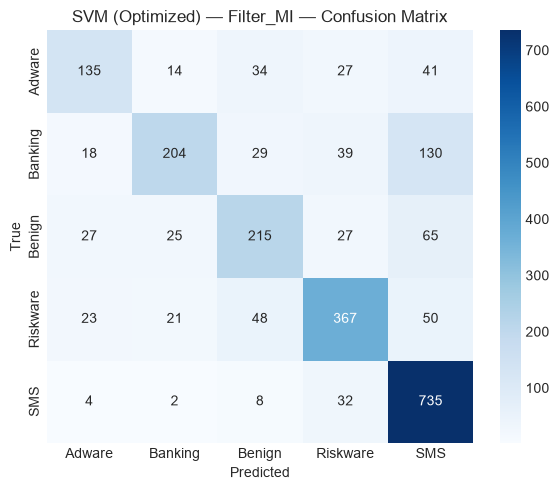

 Testing SVM (GridSearchCV) on Feature Set: Filter_Chi2
 Training Time: 62.26s |  Best Params: {'clf__C': 1000, 'clf__gamma': 1, 'clf__kernel': 'rbf'}

 predict Time: 0.43 seconds

=== SVM (Optimized) — Filter_Chi2 ===
Accuracy : 0.8754   Precision : 0.8772   Recall : 0.8754   Weighted F1 : 0.8754   Macro F1: 0.8486
              precision    recall  f1-score   support

      Adware       0.70      0.81      0.75       251
     Banking       0.89      0.85      0.87       420
      Benign       0.83      0.77      0.80       359
    Riskware       0.88      0.84      0.86       509
         SMS       0.95      0.98      0.96       781

    accuracy                           0.88      2320
   macro avg       0.85      0.85      0.85      2320
weighted avg       0.88      0.88      0.88      2320



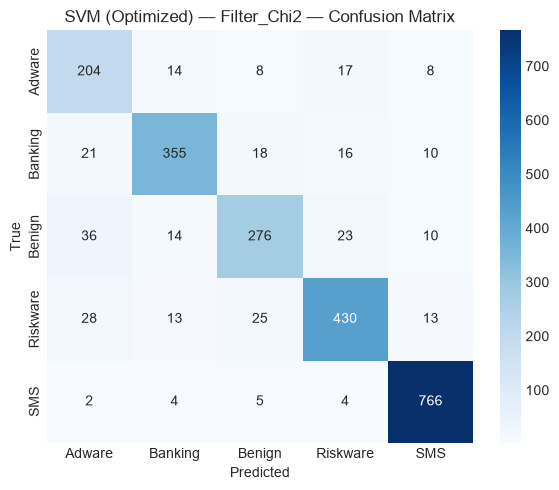

 Testing SVM (GridSearchCV) on Feature Set: Wrapper_RFECV
 Training Time: 260.51s |  Best Params: {'clf__C': 1000, 'clf__gamma': 1, 'clf__kernel': 'rbf'}

 predict Time: 0.58 seconds

=== SVM (Optimized) — Wrapper_RFECV ===
Accuracy : 0.8935   Precision : 0.8932   Recall : 0.8935   Weighted F1 : 0.8931   Macro F1: 0.8723
              precision    recall  f1-score   support

      Adware       0.78      0.82      0.80       251
     Banking       0.89      0.87      0.88       420
      Benign       0.86      0.82      0.84       359
    Riskware       0.88      0.86      0.87       509
         SMS       0.96      0.98      0.97       781

    accuracy                           0.89      2320
   macro avg       0.87      0.87      0.87      2320
weighted avg       0.89      0.89      0.89      2320



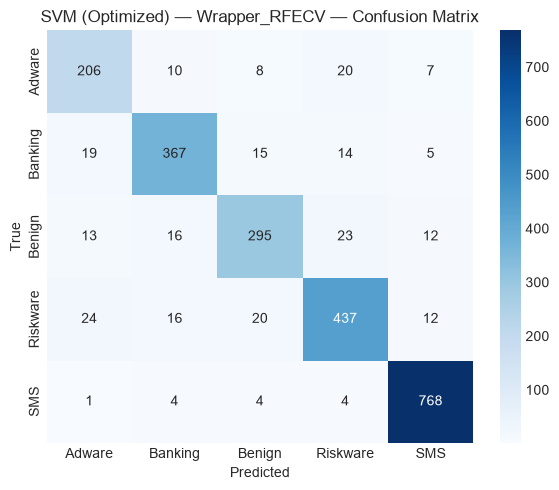

 Testing SVM (GridSearchCV) on Feature Set: Wrapper_Forward
 Training Time: 60.97s |  Best Params: {'clf__C': 1000, 'clf__gamma': 1, 'clf__kernel': 'rbf'}

 predict Time: 0.83 seconds

=== SVM (Optimized) — Wrapper_Forward ===
Accuracy : 0.7448   Precision : 0.7425   Recall : 0.7448   Weighted F1 : 0.7393   Macro F1: 0.7058
              precision    recall  f1-score   support

      Adware       0.66      0.53      0.59       251
     Banking       0.78      0.61      0.69       420
      Benign       0.65      0.68      0.66       359
    Riskware       0.75      0.73      0.74       509
         SMS       0.79      0.92      0.85       781

    accuracy                           0.74      2320
   macro avg       0.72      0.70      0.71      2320
weighted avg       0.74      0.74      0.74      2320



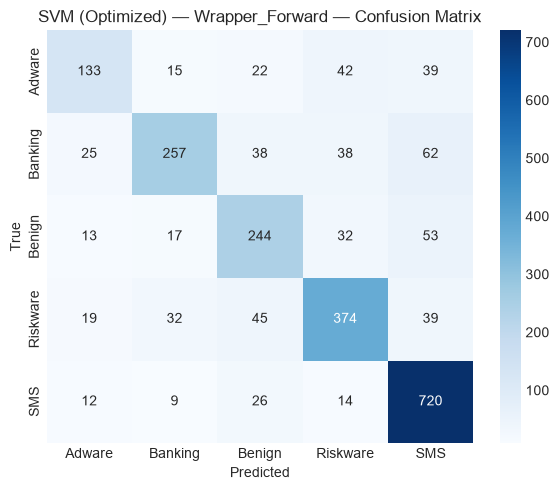


 GridSearchCV completed for selected features only!


In [20]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import time

def _make_svc_pipeline():
    return Pipeline([('clf', SVC( random_state=42))])

param_grid_svm =param_grid = {'clf__C': [0.1, 1, 10, 100, 1000], 
			'clf__gamma': [1, 0.1, 0.01, 0.001, 0.0001], 
			'clf__kernel': ['rbf']}
sCV_svm = StratifiedKFold(n_splits=5, shuffle=True, random_state=1000)

print(" Starting SVM + GridSearchCV Evaluation ON SELECTED FEATURES ONLY...\n")

for fs_name, (X_tr, X_te) in FEATURE_SETS.items():
    
    #
    if fs_name == 'Full_Features':
        continue
        
    print(f"{'='*60}\n Testing SVM (GridSearchCV) on Feature Set: {fs_name}\n{'='*60}")

  
    grid_search = GridSearchCV(
        estimator=_make_svc_pipeline(),
        param_grid=param_grid_svm,
        cv=sCV_svm,
        scoring='f1_weighted',
        n_jobs=-1
    )

    start_time = time.time()
    grid_search.fit(X_tr, y_train)
    train_time = time.time() - start_time

    print(f" Training Time: {train_time:.2f}s |  Best Params: {grid_search.best_params_}")
    start_pred = time.time()   
    y_pred = grid_search.best_estimator_.predict(X_te)
    pred_time = time.time() - start_pred

    label = f'SVM (Optimized) — {fs_name}'
    print(f"\n predict Time: {pred_time:.2f} seconds")
    acc, prec, rec, f1, macro = evaluate(label, y_test, y_pred)
    RESULTS[label] =  {'Accuracy': acc,'Weighted F1': f1,'Macro F1': macro,'Train Time (s)': train_time,    'Predict Time (s)': pred_time    
                ,'Best_Params': grid_search.best_params_}

print("\n GridSearchCV completed for selected features only!")


 Starting MLP + GridSearchCV Evaluation ON SELECTED FEATURES ONLY...

 Testing MLP (GridSearchCV) on Feature Set: Filter_MI
 Training Time: 55.80s |  Best Params: {'clf__activation': 'relu', 'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (128, 64, 32), 'clf__learning_rate': 'constant', 'clf__learning_rate_init': 0.01, 'clf__solver': 'adam'}

 predict Time: 0.01 seconds

=== MLP (Optimized) — Filter_MI ===
Accuracy : 0.7810   Precision : 0.7842   Recall : 0.7810   Weighted F1 : 0.7793   Macro F1: 0.7391
              precision    recall  f1-score   support

      Adware       0.64      0.58      0.61       251
     Banking       0.79      0.69      0.74       420
      Benign       0.60      0.73      0.66       359
    Riskware       0.83      0.72      0.77       509
         SMS       0.88      0.96      0.92       781

    accuracy                           0.78      2320
   macro avg       0.75      0.74      0.74      2320
weighted avg       0.78      0.78      0.78      2320



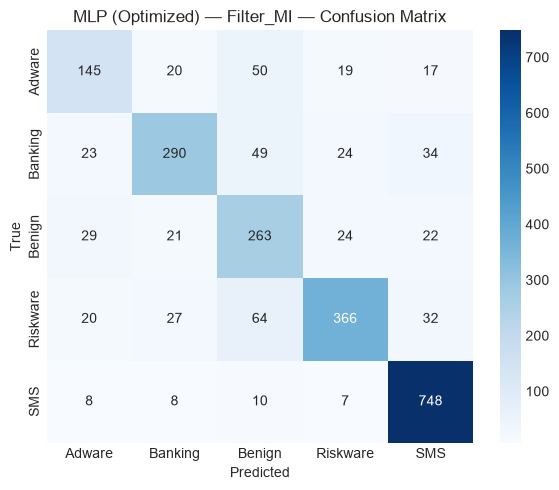

 Testing MLP (GridSearchCV) on Feature Set: Filter_Chi2
 Training Time: 63.12s |  Best Params: {'clf__activation': 'relu', 'clf__alpha': 0.001, 'clf__hidden_layer_sizes': (128, 64, 32), 'clf__learning_rate': 'constant', 'clf__learning_rate_init': 0.01, 'clf__solver': 'adam'}

 predict Time: 0.01 seconds

=== MLP (Optimized) — Filter_Chi2 ===
Accuracy : 0.8603   Precision : 0.8609   Recall : 0.8603   Weighted F1 : 0.8603   Macro F1: 0.8326
              precision    recall  f1-score   support

      Adware       0.70      0.75      0.72       251
     Banking       0.86      0.83      0.84       420
      Benign       0.82      0.77      0.80       359
    Riskware       0.84      0.85      0.85       509
         SMS       0.94      0.96      0.95       781

    accuracy                           0.86      2320
   macro avg       0.83      0.83      0.83      2320
weighted avg       0.86      0.86      0.86      2320



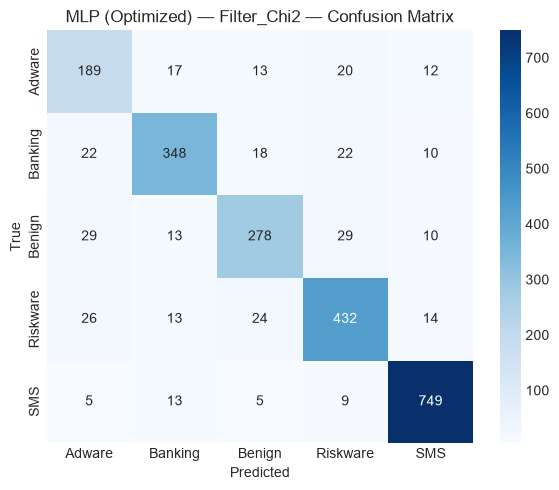

 Testing MLP (GridSearchCV) on Feature Set: Wrapper_RFECV
 Training Time: 128.20s |  Best Params: {'clf__activation': 'relu', 'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (128, 64, 32), 'clf__learning_rate': 'constant', 'clf__learning_rate_init': 0.01, 'clf__solver': 'adam'}

 predict Time: 0.01 seconds

=== MLP (Optimized) — Wrapper_RFECV ===
Accuracy : 0.8935   Precision : 0.8949   Recall : 0.8935   Weighted F1 : 0.8933   Macro F1: 0.8743
              precision    recall  f1-score   support

      Adware       0.82      0.80      0.81       251
     Banking       0.93      0.84      0.88       420
      Benign       0.80      0.88      0.84       359
    Riskware       0.90      0.87      0.89       509
         SMS       0.94      0.97      0.96       781

    accuracy                           0.89      2320
   macro avg       0.88      0.87      0.87      2320
weighted avg       0.89      0.89      0.89      2320



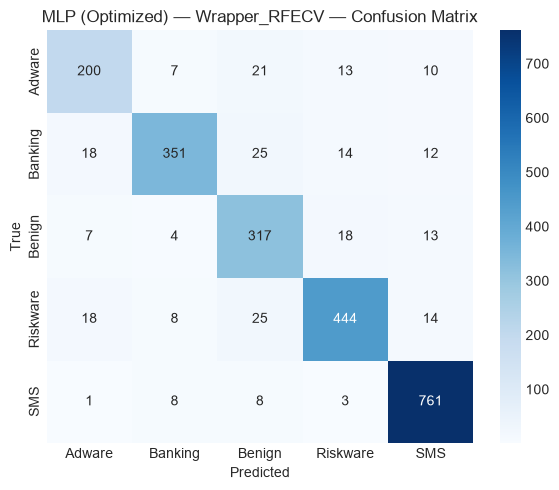

 Testing MLP (GridSearchCV) on Feature Set: Wrapper_Forward
 Training Time: 56.31s |  Best Params: {'clf__activation': 'relu', 'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (128, 64, 32), 'clf__learning_rate': 'constant', 'clf__learning_rate_init': 0.01, 'clf__solver': 'adam'}

 predict Time: 0.01 seconds

=== MLP (Optimized) — Wrapper_Forward ===
Accuracy : 0.8159   Precision : 0.8231   Recall : 0.8159   Weighted F1 : 0.8146   Macro F1: 0.7852
              precision    recall  f1-score   support

      Adware       0.62      0.77      0.69       251
     Banking       0.89      0.69      0.77       420
      Benign       0.83      0.69      0.75       359
    Riskware       0.77      0.82      0.79       509
         SMS       0.88      0.96      0.92       781

    accuracy                           0.82      2320
   macro avg       0.80      0.78      0.79      2320
weighted avg       0.82      0.82      0.81      2320



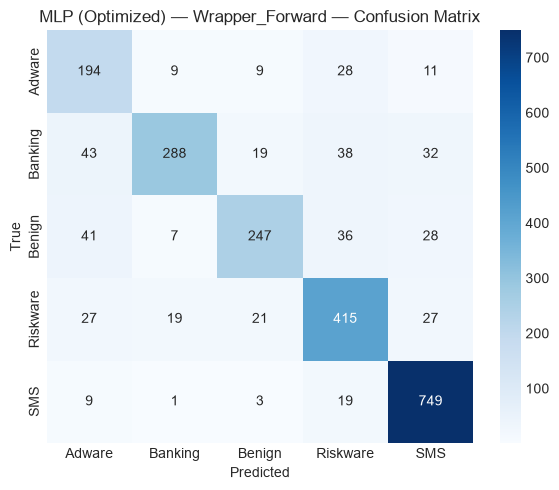


 GridSearchCV completed for selected features only (MLP)!


In [21]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import time

def _make_mlp_pipeline():
    return Pipeline([('clf', MLPClassifier(
        activation='relu', solver='adam', batch_size=256,
        max_iter=50, early_stopping=True, validation_fraction=0.1,
        n_iter_no_change=5, random_state=42))])

param_grid_mlp = param_grid_mlp_maldroid = {
    'clf__hidden_layer_sizes': [(100,), (64, 32), (128, 64, 32)],
    'clf__activation': ['relu'],
    'clf__solver': ['adam', 'sgd'],
    'clf__alpha': [0.0001, 0.001, 0.01],
    'clf__learning_rate': ['constant', 'adaptive'],
    'clf__learning_rate_init': [0.001, 0.01]
}
sCV_mlp = StratifiedKFold(n_splits=5, shuffle=True, random_state=1000)  
print(" Starting MLP + GridSearchCV Evaluation ON SELECTED FEATURES ONLY...\n")

for fs_name, (X_tr, X_te) in FEATURE_SETS.items():
    
    if fs_name == 'Full_Features':
        continue
        
    print(f"{'='*60}\n Testing MLP (GridSearchCV) on Feature Set: {fs_name}\n{'='*60}")

    grid_search = GridSearchCV(
        estimator=_make_mlp_pipeline(),
        param_grid=param_grid_mlp,
        cv=sCV_mlp,
        scoring='f1_weighted',
        n_jobs=-1  
    )

    start_time = time.time()
    grid_search.fit(X_tr, y_train)
    train_time = time.time() - start_time

    print(f" Training Time: {train_time:.2f}s |  Best Params: {grid_search.best_params_}")
    start_pred = time.time()   
    y_pred = grid_search.best_estimator_.predict(X_te)
    pred_time = time.time() - start_pred

   
    print(f"\n predict Time: {pred_time:.2f} seconds")
    label = f'MLP (Optimized) — {fs_name}'
    
    acc, prec, rec, f1, macro = evaluate(label, y_test, y_pred)
    RESULTS[label] =  {'Accuracy': acc,'Weighted F1': f1,'Macro F1': macro,'Train Time (s)': train_time,    'Predict Time (s)': pred_time    
                ,'Best_Params': grid_search.best_params_}

print("\n GridSearchCV completed for selected features only (MLP)!")

 Starting XGBoost + GridSearchCV Evaluation ON SELECTED FEATURES ONLY...

 Testing XGBoost on Feature Set: Filter_MI (Features Count: 30)
 Training Time: 152.49 seconds
 Best Hyperparameters found: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 6, 'clf__min_child_weight': 1, 'clf__n_estimators': 100, 'clf__subsample': 0.8}

 predict Time: 0.01 seconds

=== XGBoost (Optimized) — Filter_MI ===
Accuracy : 0.8987   Precision : 0.8983   Recall : 0.8987   Weighted F1 : 0.8984   Macro F1: 0.8774
              precision    recall  f1-score   support

      Adware       0.82      0.82      0.82       251
     Banking       0.89      0.87      0.88       420
      Benign       0.82      0.82      0.82       359
    Riskware       0.90      0.88      0.89       509
         SMS       0.96      0.98      0.97       781

    accuracy                           0.90      2320
   macro avg       0.88      0.88      0.88      2320
weighted avg       0.90      0.90      0.9

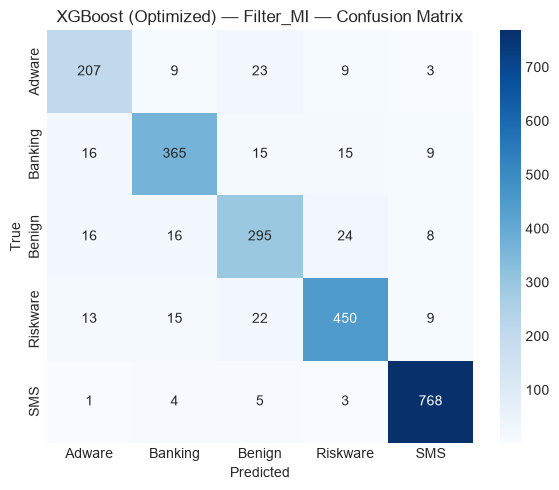

 Testing XGBoost on Feature Set: Filter_Chi2 (Features Count: 30)
 Training Time: 132.39 seconds
 Best Hyperparameters found: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 6, 'clf__min_child_weight': 1, 'clf__n_estimators': 100, 'clf__subsample': 0.8}

 predict Time: 0.01 seconds

=== XGBoost (Optimized) — Filter_Chi2 ===
Accuracy : 0.9039   Precision : 0.9038   Recall : 0.9039   Weighted F1 : 0.9038   Macro F1: 0.8820
              precision    recall  f1-score   support

      Adware       0.79      0.80      0.80       251
     Banking       0.91      0.89      0.90       420
      Benign       0.84      0.85      0.84       359
    Riskware       0.90      0.89      0.89       509
         SMS       0.97      0.98      0.97       781

    accuracy                           0.90      2320
   macro avg       0.88      0.88      0.88      2320
weighted avg       0.90      0.90      0.90      2320



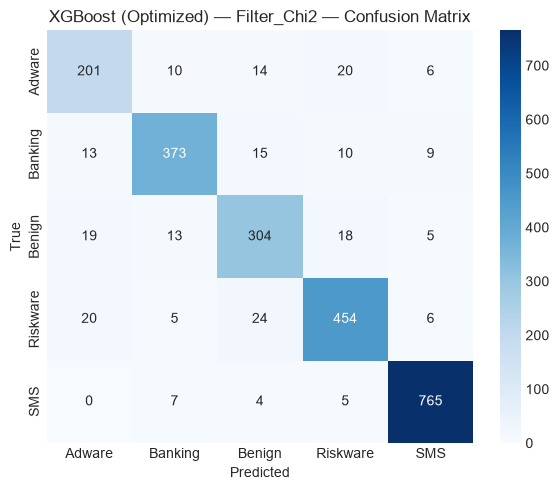

 Testing XGBoost on Feature Set: Wrapper_RFECV (Features Count: 190)
 Training Time: 621.21 seconds
 Best Hyperparameters found: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 6, 'clf__min_child_weight': 1, 'clf__n_estimators': 100, 'clf__subsample': 0.8}

 predict Time: 0.01 seconds

=== XGBoost (Optimized) — Wrapper_RFECV ===
Accuracy : 0.9405   Precision : 0.9407   Recall : 0.9405   Weighted F1 : 0.9405   Macro F1: 0.9304
              precision    recall  f1-score   support

      Adware       0.89      0.91      0.90       251
     Banking       0.95      0.90      0.93       420
      Benign       0.91      0.93      0.92       359
    Riskware       0.92      0.92      0.92       509
         SMS       0.98      0.99      0.98       781

    accuracy                           0.94      2320
   macro avg       0.93      0.93      0.93      2320
weighted avg       0.94      0.94      0.94      2320



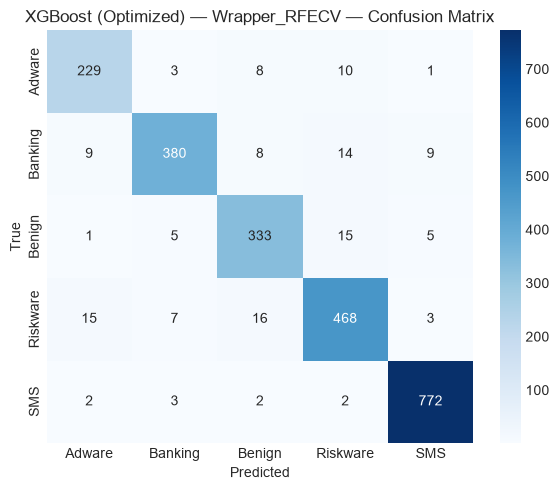

 Testing XGBoost on Feature Set: Wrapper_Forward (Features Count: 20)
 Training Time: 78.27 seconds
 Best Hyperparameters found: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 6, 'clf__min_child_weight': 1, 'clf__n_estimators': 100, 'clf__subsample': 0.8}

 predict Time: 0.01 seconds

=== XGBoost (Optimized) — Wrapper_Forward ===
Accuracy : 0.9190   Precision : 0.9188   Recall : 0.9190   Weighted F1 : 0.9188   Macro F1: 0.9032
              precision    recall  f1-score   support

      Adware       0.85      0.86      0.85       251
     Banking       0.92      0.89      0.90       420
      Benign       0.88      0.88      0.88       359
    Riskware       0.91      0.90      0.90       509
         SMS       0.97      0.98      0.98       781

    accuracy                           0.92      2320
   macro avg       0.90      0.90      0.90      2320
weighted avg       0.92      0.92      0.92      2320



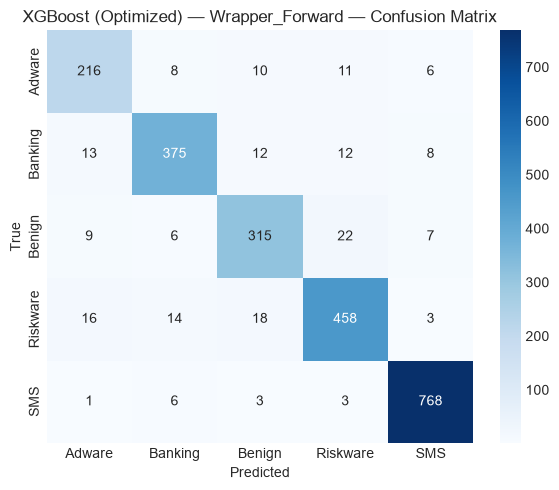


 All XGBoost models optimized and evaluated successfully on selected features!


In [23]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import xgboost as xgb
import time

param_grid_xgb = param_grid_xgb_maldroid = {
    'clf__n_estimators': [100, 300],              
    'clf__learning_rate': [0.05, 0.1, 0.2],       
    'clf__max_depth': [6, 10],                    
    'clf__min_child_weight': [1, 3],              
    'clf__subsample': [0.8, 1.0],                 
    'clf__colsample_bytree': [0.8, 1.0]           
}
sCV = StratifiedKFold(n_splits=5, shuffle=True, random_state=1000)

print(" Starting XGBoost + GridSearchCV Evaluation ON SELECTED FEATURES ONLY...\n")

for fs_name, (X_tr, X_te) in FEATURE_SETS.items():
    
    if fs_name == 'Full_Features':
        continue
        
    print(f"{'='*60}")
    print(f" Testing XGBoost on Feature Set: {fs_name} (Features Count: {X_tr.shape[1]})")
    print(f"{'='*60}")
    
    xgb_clf = xgb.XGBClassifier(verbosity=0, random_state=42, n_jobs=-1)
    
    grid_search = GridSearchCV(
        estimator=xgb_clf,
        param_grid=param_grid_xgb,
        cv=sCV,
        scoring='f1_weighted',
        n_jobs=-1
    )
    
    start_time = time.time()
    grid_search.fit(X_tr, y_train)
    train_time = time.time() - start_time
    
    print(f" Training Time: {train_time:.2f} seconds")
    print(f" Best Hyperparameters found: {grid_search.best_params_}")
    
    best_model = grid_search.best_estimator_
    start_pred = time.time()   
    y_pred = best_model.predict(X_te)
    pred_time = time.time() - start_pred

   
    print(f"\n predict Time: {pred_time:.2f} seconds")
    label = f'XGBoost (Optimized) — {fs_name}'
    
    acc, prec, rec, f1, macro = evaluate(label, y_test, y_pred)
    
    RESULTS[label] =  {'Accuracy': acc,'Weighted F1': f1,'Macro F1': macro,'Train Time (s)': train_time,    'Predict Time (s)': pred_time    
                ,'Best_Params': grid_search.best_params_}

print("\n All XGBoost models optimized and evaluated successfully on selected features!")



                            Algorithm Accuracy Weighted F1 Macro F1 Train Time Predict Time
   XGBoost (Baseline) — Full_Features   0.9409      0.9408   0.9317      5.09s        0.05s
   XGBoost (Baseline) — Wrapper_RFECV   0.9405      0.9405   0.9304      2.91s        0.00s
  XGBoost (Optimized) — Wrapper_RFECV   0.9405      0.9405   0.9304    621.21s        0.01s
XGBoost (Optimized) — Wrapper_Forward   0.9190      0.9188   0.9032     78.27s        0.01s
 XGBoost (Baseline) — Wrapper_Forward   0.9190      0.9188   0.9032      0.47s        0.00s
     XGBoost (Baseline) — Filter_Chi2   0.9039      0.9038   0.8820      0.72s        0.01s
    XGBoost (Optimized) — Filter_Chi2   0.9039      0.9038   0.8820    132.39s        0.01s
      XGBoost (Optimized) — Filter_MI   0.8987      0.8984   0.8774    152.49s        0.01s
       XGBoost (Baseline) — Filter_MI   0.8987      0.8984   0.8774      0.76s        0.01s
      MLP (Optimized) — Wrapper_RFECV   0.8935      0.8933   0.8743    128.20s

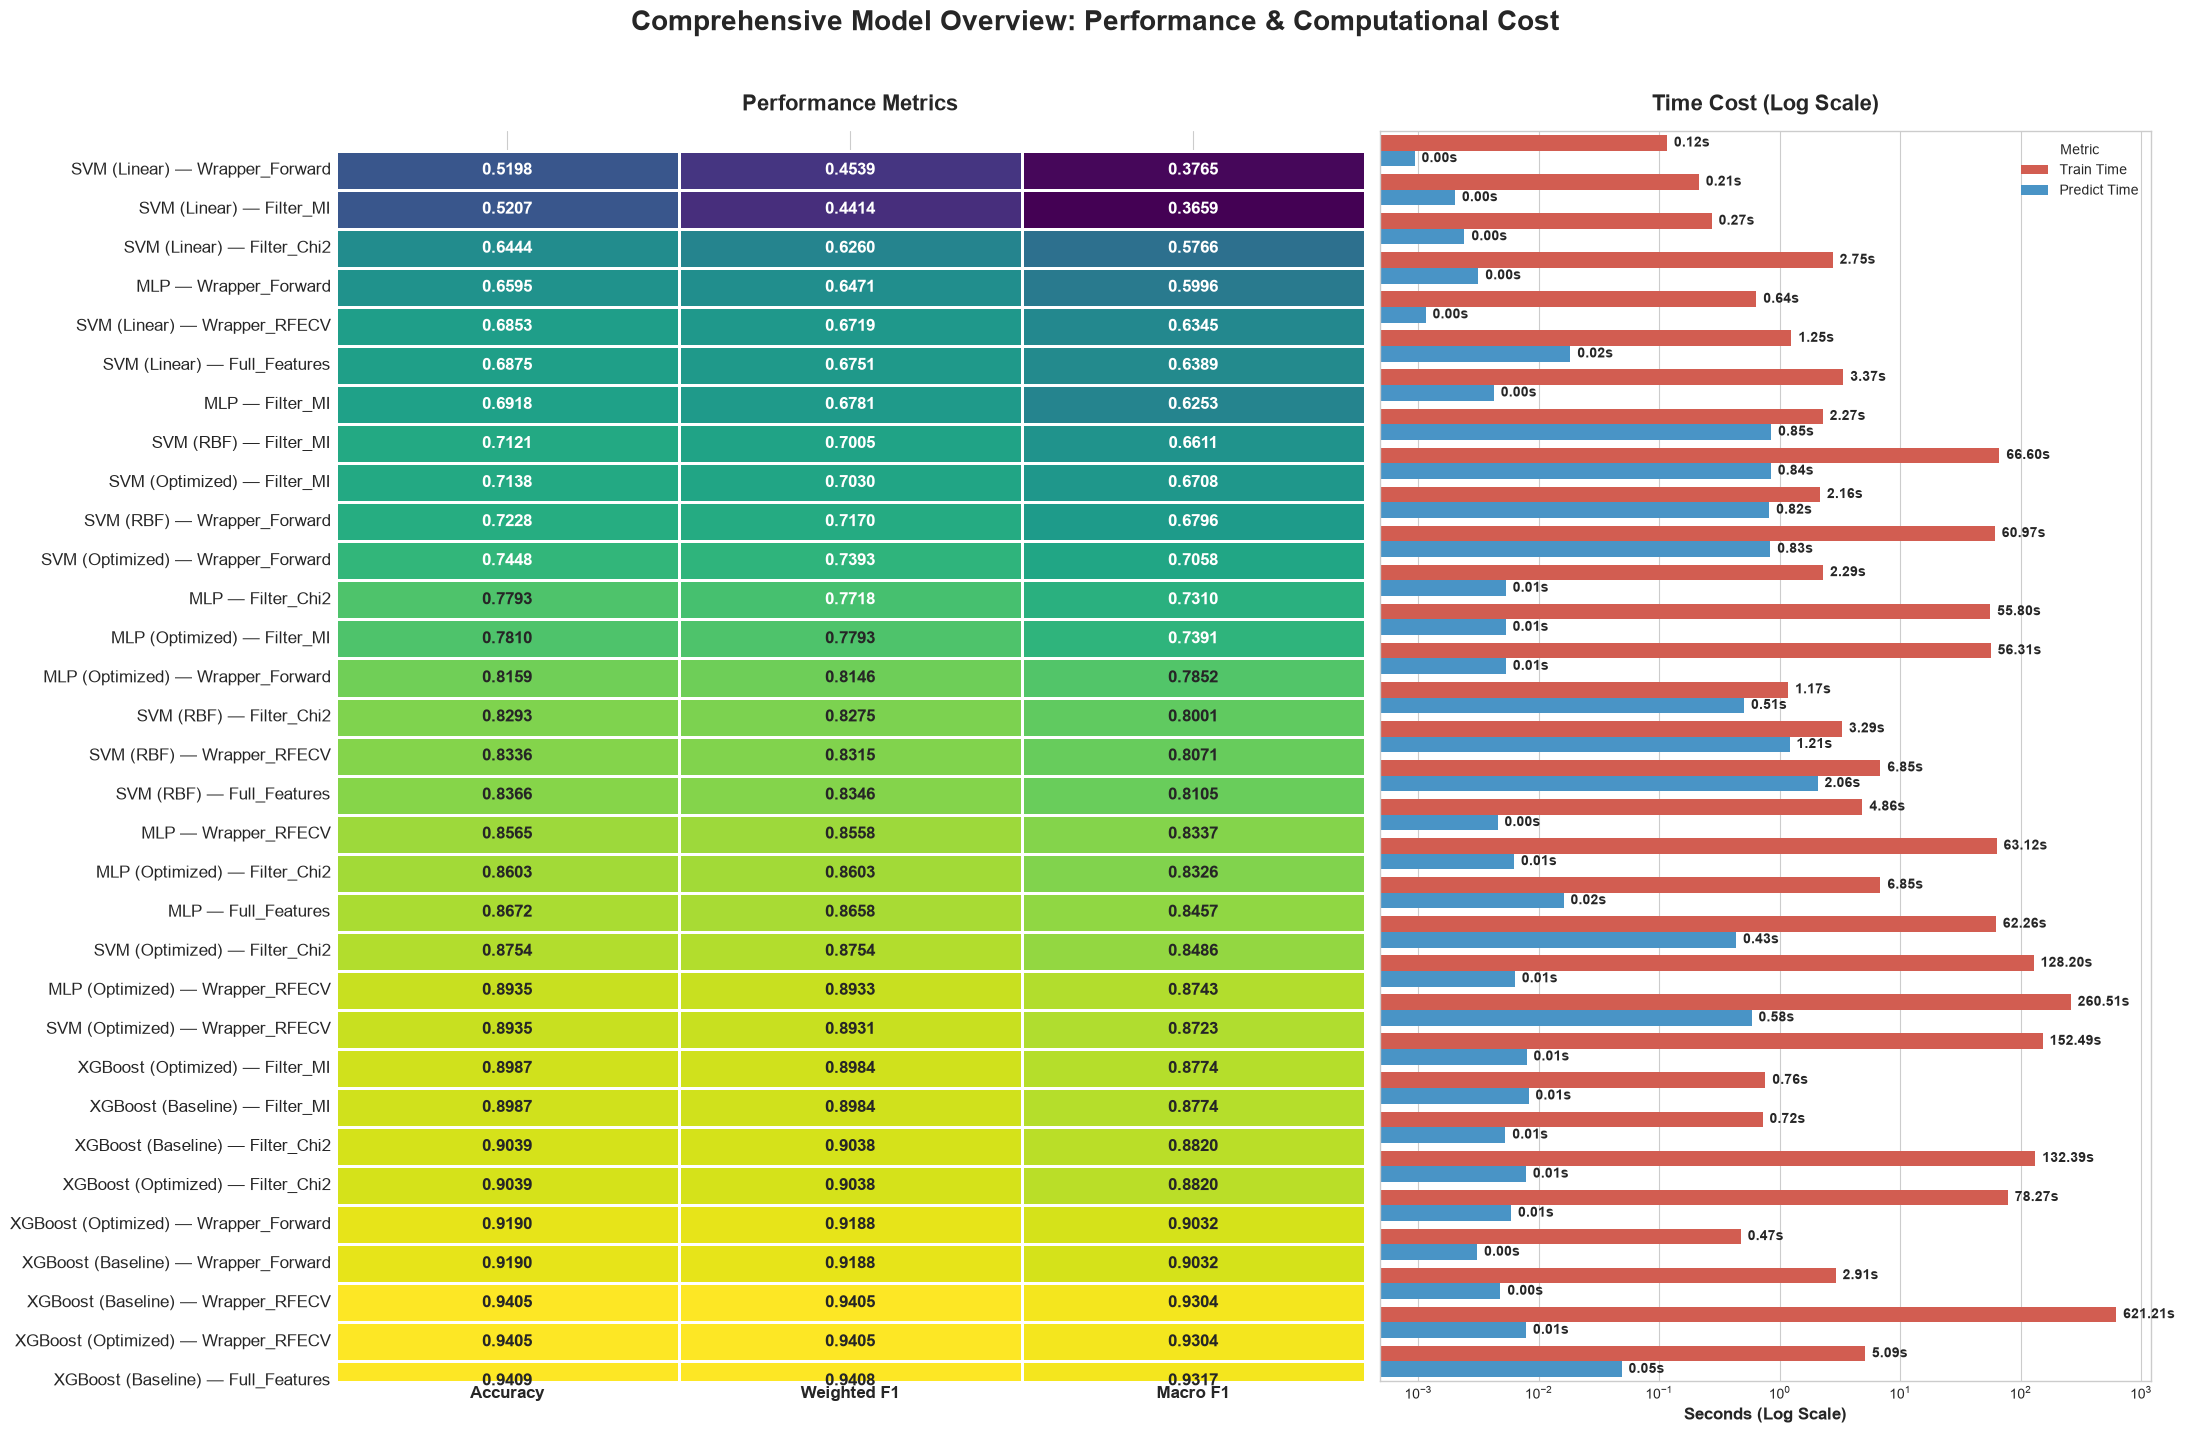

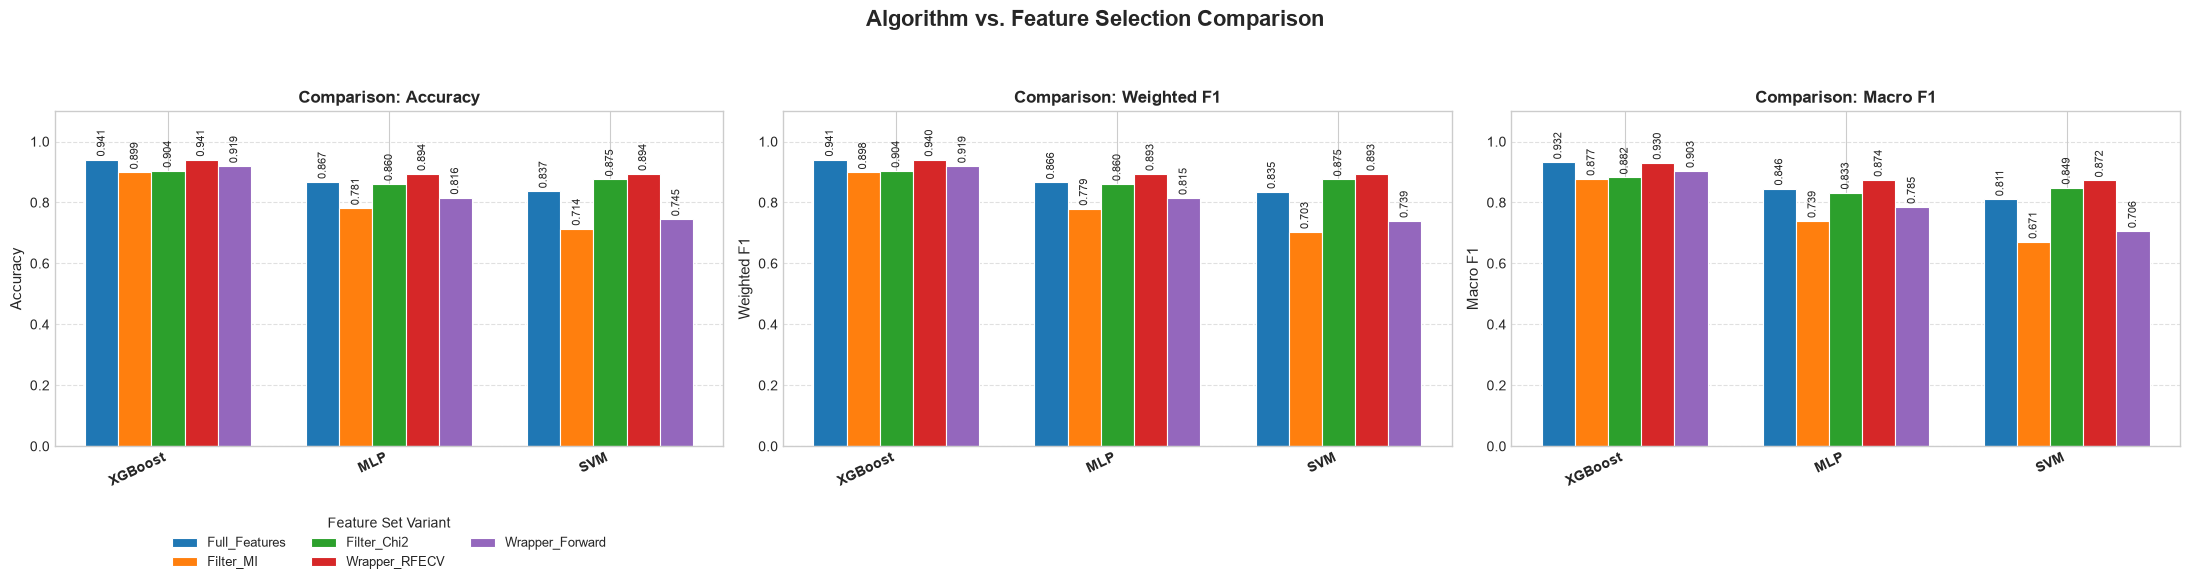



 Filter Impact vs. Full-Features Baseline (Positive = Improvement) 

Model Family     Feature Set Δ Accuracy Δ Macro F1 Train Time Predict Time
     XGBoost       Filter_MI    -0.0422    -0.0543    152.49s      0.0079s
     XGBoost     Filter_Chi2    -0.0371    -0.0497      0.72s      0.0053s
     XGBoost   Wrapper_RFECV    -0.0004    -0.0013      2.91s      0.0048s
     XGBoost Wrapper_Forward    -0.0220    -0.0285     78.27s      0.0059s
         MLP       Filter_MI    -0.0862    -0.1066     55.80s      0.0053s
         MLP     Filter_Chi2    -0.0069    -0.0131     63.12s      0.0062s
         MLP   Wrapper_RFECV    +0.0263    +0.0285    128.20s      0.0063s
         MLP Wrapper_Forward    -0.0513    -0.0605     56.31s      0.0053s
         SVM       Filter_MI    -0.1228    -0.1397     66.60s      0.8432s
         SVM     Filter_Chi2    +0.0388    +0.0381     62.26s      0.4340s
         SVM   Wrapper_RFECV    +0.0569    +0.0618    260.51s      0.5833s
         SVM Wrapper_Forward 

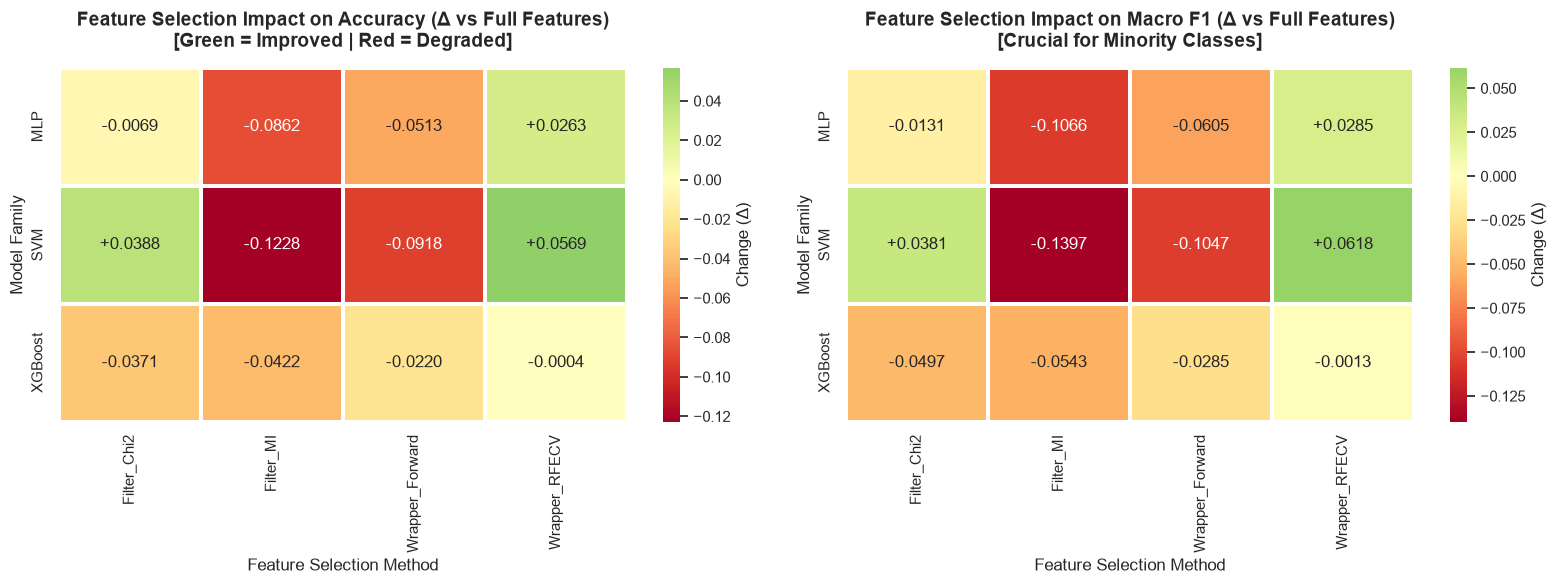

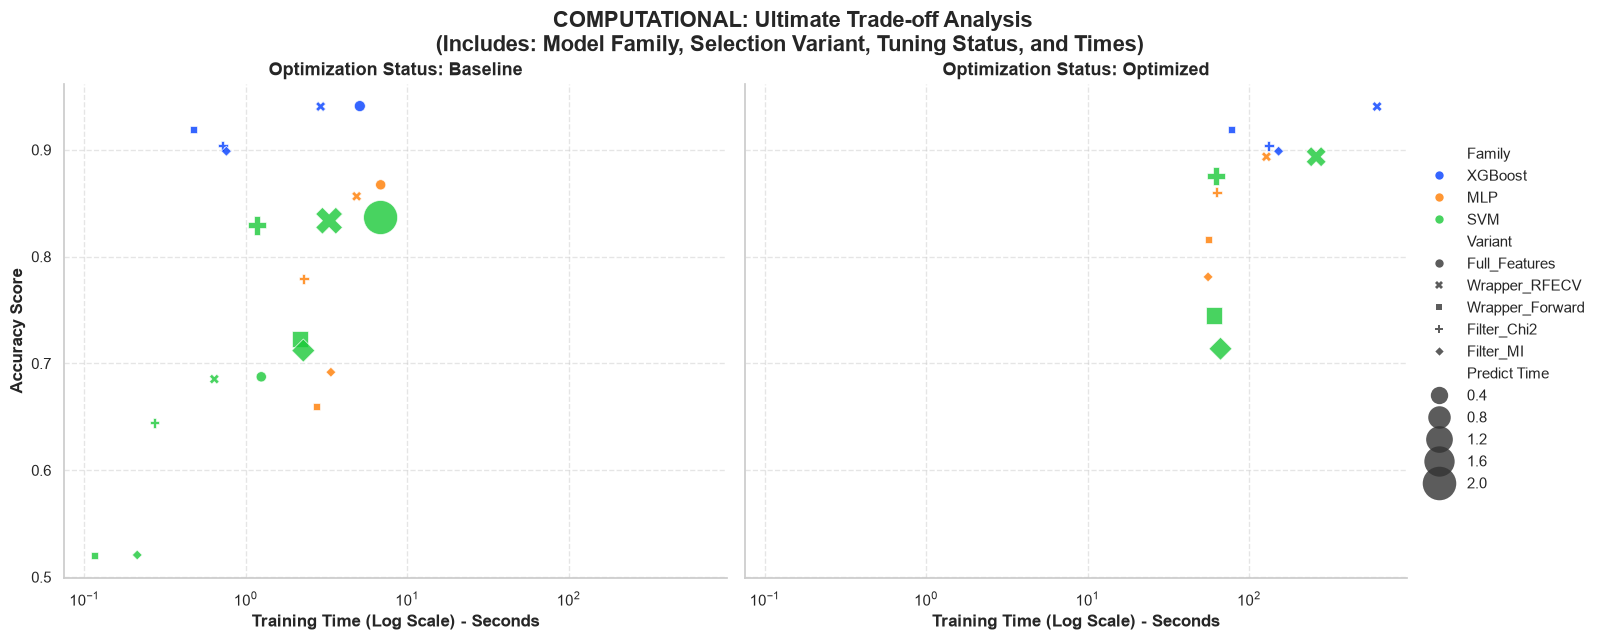

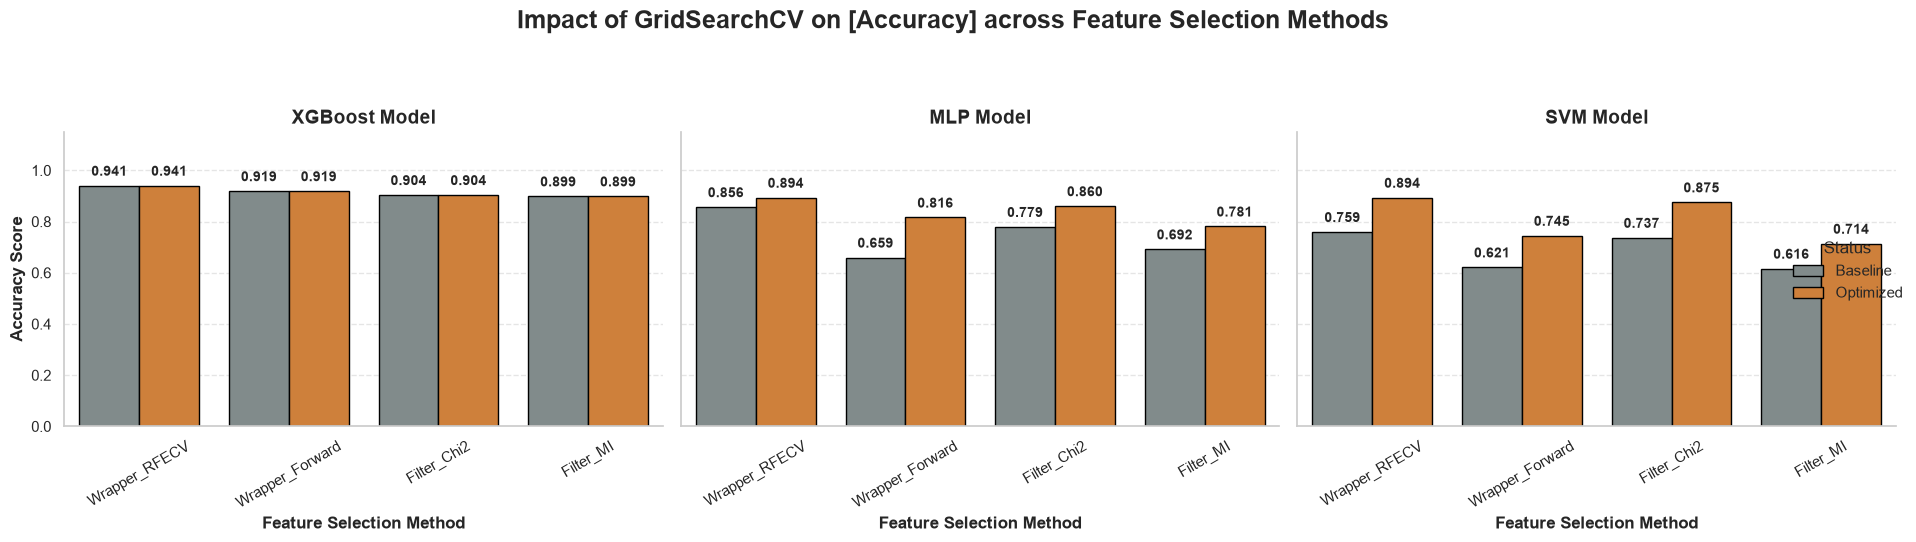

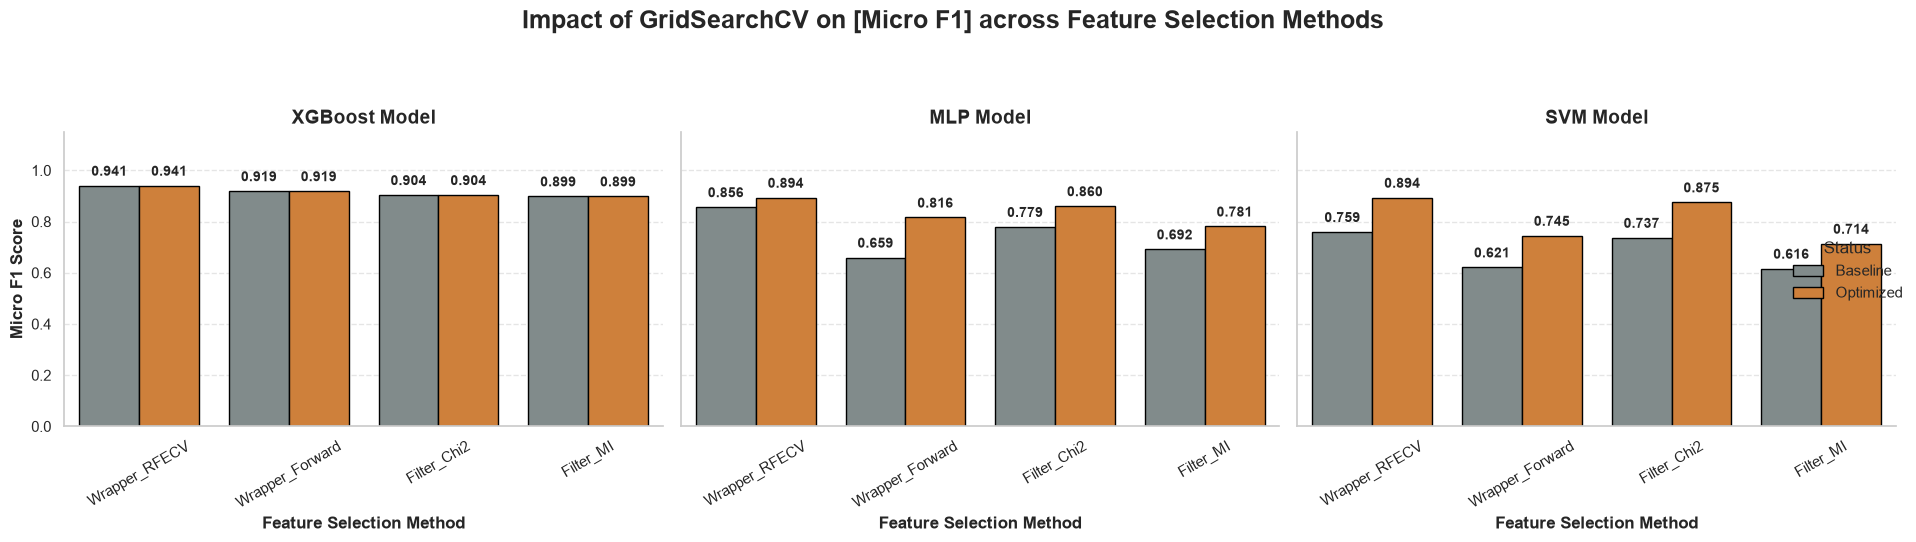

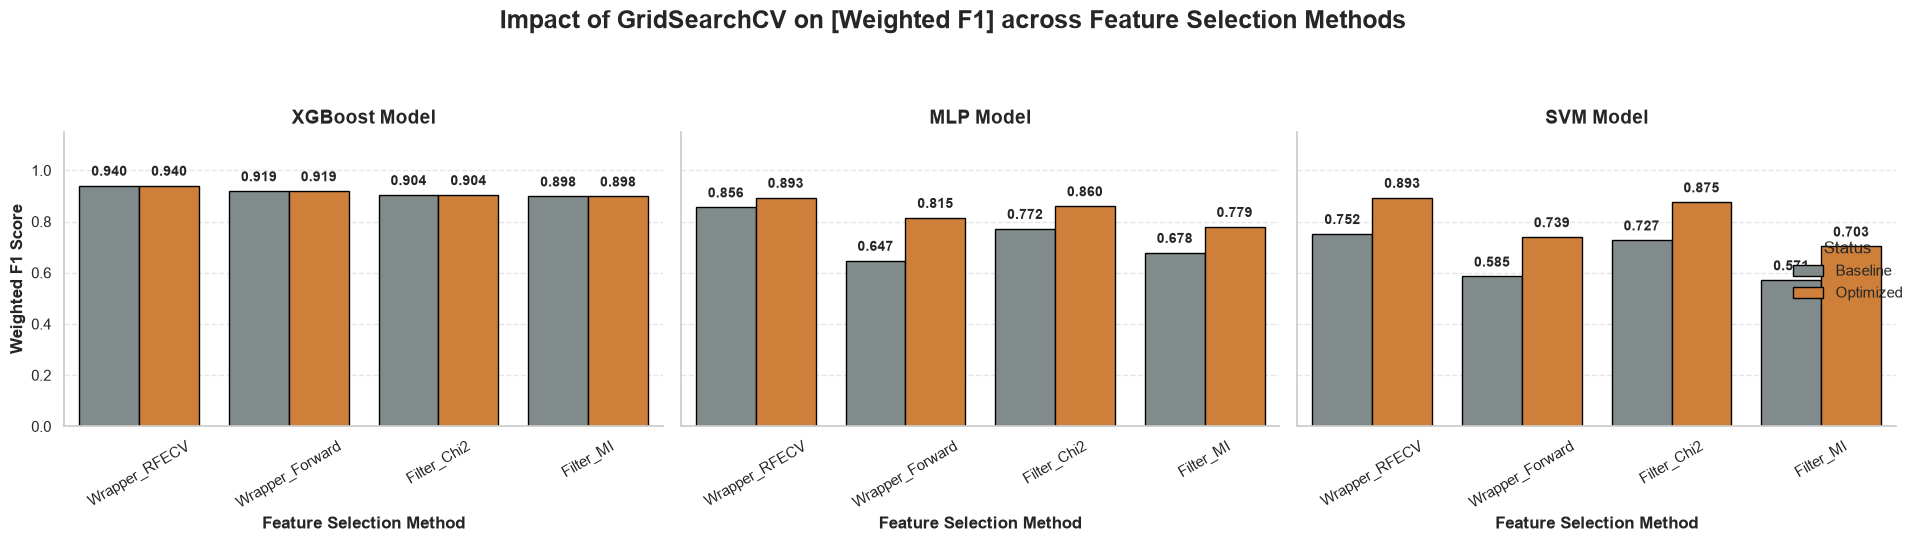

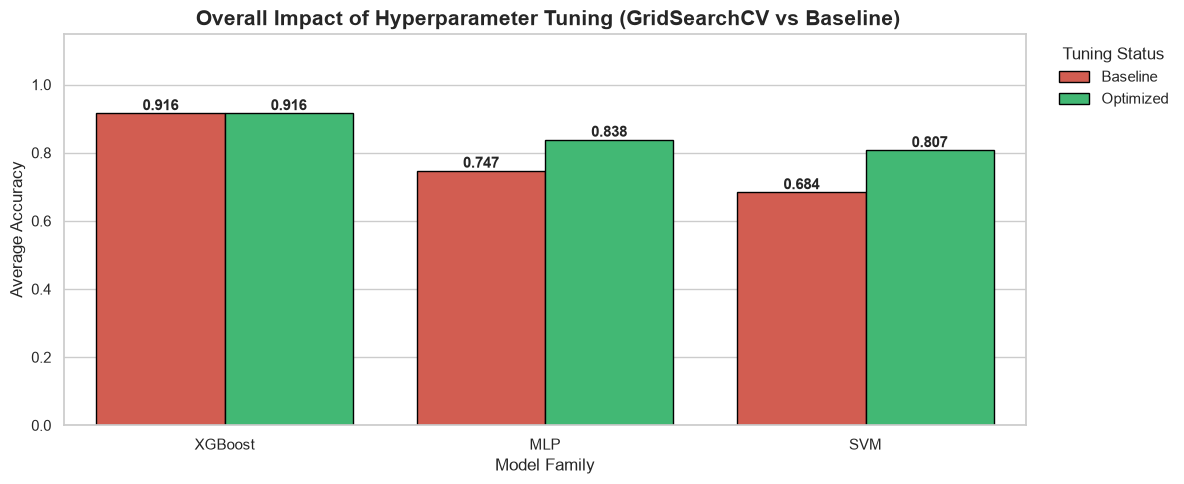

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

def _safe_float(v):
    try:
        val = float(v)
        return val if not np.isnan(val) else float('nan')
    except (TypeError, ValueError):
        return float('nan')

_rows = []
for name, metrics in RESULTS.items():
    train_time = (metrics.get('Train Time (s)') or 
                  metrics.get('Train Time') or 
                  metrics.get('Time') or 0)
                  
    pred_time = (metrics.get('Predict Time (s)') or 
                 metrics.get('Predict Time') or 0)
        
    _rows.append({
        'Algorithm'   : name,
        'Accuracy'    : _safe_float(metrics.get('Accuracy')),
        'Weighted F1' : _safe_float(metrics.get('Weighted F1', metrics.get('F1'))),
        'Macro F1'    : _safe_float(metrics.get('Macro F1')),
        'Train Time'  : _safe_float(train_time),
        'Predict Time': _safe_float(pred_time)
    })

results_df = pd.DataFrame(_rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)

def _parse(name):
    clean_name = str(name).replace('===', '').replace('', '').strip()
    
    variant = 'Full_Features'
    for v in ['Filter_MI', 'Filter_Chi2', 'Wrapper_RFECV', 'Wrapper_Forward']:
        if v.lower() in clean_name.lower():
            variant = v
            break
            
    if variant == 'Full_Features':
        status = 'Baseline'
    else:
        
        status = 'Optimized' if 'Optimized' in clean_name else 'Baseline'
    
    if 'SVM' in clean_name: family = 'SVM'
    elif 'MLP' in clean_name: family = 'MLP'
    elif 'XGBoost' in clean_name: family = 'XGBoost'
    else: family = clean_name.split('—')[0].split('-')[0].strip()
        
    return family, status, variant

parsed_data = results_df['Algorithm'].apply(lambda n: pd.Series(_parse(n)))
results_df['Family'] = parsed_data[0]
results_df['Status'] = parsed_data[1]
results_df['Variant'] = parsed_data[2]

results_df = results_df[~((results_df['Variant'] == 'Full_Features') & 
                          (results_df['Algorithm'].str.contains('Optimized', case=False, na=False)))].reset_index(drop=True)

pretty = results_df.copy()
for col in ['Accuracy', 'Weighted F1', 'Macro F1']:
    pretty[col] = pretty[col].map(lambda x: f'{x:.4f}' if not pd.isna(x) else 'N/A')
for col in ['Train Time', 'Predict Time']:
    pretty[col] = pretty[col].map(lambda x: f'{x:.2f}s' if not pd.isna(x) and x > 0 else 'N/A')

print(''*95)

print(''*95)
print(pretty[['Algorithm', 'Accuracy', 'Weighted F1', 'Macro F1', 'Train Time', 'Predict Time']].to_string(index=False))
print('\n')

clean_df = results_df.dropna(subset=['Accuracy']).copy()
df_comprehensive = clean_df.sort_values('Accuracy', ascending=True).copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 14), gridspec_kw={'width_ratios': [2, 1.5]}, sharey=True)

metrics_cols = ['Accuracy', 'Weighted F1', 'Macro F1']
metrics_df = df_comprehensive.set_index('Algorithm')[metrics_cols]

sns.heatmap(metrics_df, annot=True, fmt=".4f", cmap="viridis", cbar=False, 
            linewidths=1, linecolor='white', ax=ax1, annot_kws={"size": 12, "weight": "bold"})

ax1.set_title('Performance Metrics', fontsize=16, fontweight='bold', pad=15)
ax1.set_ylabel('')
ax1.tick_params(axis='y', labelsize=12, labelrotation=0)
ax1.tick_params(axis='x', labelsize=12)
plt.setp(ax1.get_xticklabels(), fontweight='bold')

time_df = df_comprehensive[['Algorithm', 'Train Time', 'Predict Time']].melt(id_vars='Algorithm', var_name='Metric', value_name='Time(s)')

sns.barplot(data=time_df, y='Algorithm', x='Time(s)', hue='Metric', ax=ax2, palette=['#e74c3c', '#3498db'])

ax2.set_xscale('log')
ax2.set_title('Time Cost (Log Scale)', fontsize=16, fontweight='bold', pad=15)
ax2.set_ylabel('')
ax2.set_xlabel('Seconds (Log Scale)', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', left=False)

for p in ax2.patches:
    width = p.get_width()
    if width > 0 and not np.isnan(width):
        ax2.annotate(f"{width:.2f}s", 
                     (width, p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', fontsize=10, fontweight='bold',
                     xytext=(5, 0), textcoords='offset points')

plt.suptitle('Comprehensive Model Overview: Performance & Computational Cost', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

families = results_df['Family'].drop_duplicates().tolist()
variants = ['Full_Features', 'Filter_MI', 'Filter_Chi2', 'Wrapper_RFECV', 'Wrapper_Forward']
existing_variants = [v for v in variants if v in results_df['Variant'].values]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
variant_colors = dict(zip(existing_variants, colors[:len(existing_variants)]))

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
metrics_to_plot = ['Accuracy', 'Weighted F1', 'Macro F1']

for ax, metric in zip(axes, metrics_to_plot):
    x = np.arange(len(families))
    width = 0.15  
    
    for j, v in enumerate(existing_variants):
        vals = []
        for fam in families:
            sub = results_df[(results_df['Family'] == fam) & (results_df['Variant'] == v)]
            vals.append(sub[metric].iloc[0] if len(sub) else float('nan'))
        
        offset = (j - len(existing_variants)/2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=v, color=variant_colors.get(v, '#333'), edgecolor='white', linewidth=0.8)
        
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=8, rotation=90)
    
    ax.set_xticks(x)
    ax.set_xticklabels(families, rotation=25, ha='right', fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_title(f'Comparison: {metric}', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric, fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    if metric == 'Accuracy':
        ax.legend(title='Feature Set Variant', fontsize=9, loc='lower center', bbox_to_anchor=(0.5, -0.4), ncol=3)

plt.suptitle('Algorithm vs. Feature Selection Comparison', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

delta_rows = []
for fam in families:
    base = results_df[(results_df['Family'] == fam) & (results_df['Variant'] == 'Full_Features') & (results_df['Status'] == 'Baseline')]
    if not len(base):
        base = results_df[(results_df['Family'] == fam) & (results_df['Variant'] == 'Full_Features')]
    if not len(base): continue
    
    base_acc = base['Accuracy'].iloc[0]
    base_mac = base['Macro F1'].iloc[0]
    
    for v in existing_variants:
        if v == 'Full_Features': continue
        sub = results_df[(results_df['Family'] == fam) & (results_df['Variant'] == v)]
        if not len(sub): continue
        
        delta_rows.append({
            'Model Family': fam,
            'Feature Set': v,
            'Δ Accuracy': sub['Accuracy'].iloc[0] - base_acc,
            'Δ Macro F1': sub['Macro F1'].iloc[0] - base_mac,
            'Train Time': sub['Train Time'].iloc[0],      
            'Predict Time': sub['Predict Time'].iloc[0]   
        })

delta_df = pd.DataFrame(delta_rows)
print('\n' + ''*85)
print(' Filter Impact vs. Full-Features Baseline (Positive = Improvement) ')
print(''*85)
if not delta_df.empty:
    print(delta_df.to_string(index=False, formatters={
        'Δ Accuracy': '{:+.4f}'.format, 
        'Δ Macro F1': '{:+.4f}'.format,
        'Train Time': '{:.2f}s'.format,
        'Predict Time': '{:.4f}s'.format
    }))

    print("\n" + ""*40)
    print(""*40 + "\n")
    
    sns.set_theme(style="darkgrid", palette="deep")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    pivot_acc_delta = delta_df.pivot(index='Model Family', columns='Feature Set', values='Δ Accuracy')
    pivot_mac_delta = delta_df.pivot(index='Model Family', columns='Feature Set', values='Δ Macro F1')
    
    sns.heatmap(pivot_acc_delta, annot=True, cmap='RdYlGn', center=0, fmt='+.4f', 
                linewidths=1.5, linecolor='white', cbar_kws={'label': 'Change (Δ)'}, ax=axes[0])
    axes[0].set_title('Feature Selection Impact on Accuracy (Δ vs Full Features)\n[Green = Improved | Red = Degraded]', 
                      fontweight='bold', fontsize=14, pad=15)
    axes[0].set_xlabel('Feature Selection Method', fontsize=12)
    axes[0].set_ylabel('Model Family', fontsize=12)
    
    sns.heatmap(pivot_mac_delta, annot=True, cmap='RdYlGn', center=0, fmt='+.4f', 
                linewidths=1.5, linecolor='white', cbar_kws={'label': 'Change (Δ)'}, ax=axes[1])
    axes[1].set_title('Feature Selection Impact on Macro F1 (Δ vs Full Features)\n[Crucial for Minority Classes]', 
                      fontweight='bold', fontsize=14, pad=15)
    axes[1].set_xlabel('Feature Selection Method', fontsize=12)
    axes[1].set_ylabel('Model Family', fontsize=12)
    
    plt.tight_layout()
    plt.show()

sns.set_theme(style="whitegrid")
clean_df = results_df.dropna(subset=['Accuracy']).copy()

def get_micro_f1(algo_name):
    return RESULTS.get(algo_name, {}).get('Micro F1', RESULTS.get(algo_name, {}).get('Accuracy', np.nan))
clean_df['Micro F1'] = clean_df['Algorithm'].apply(get_micro_f1)

def categorize_fs(variant):
    if 'Filter' in variant: return 'Filter Methods'
    elif 'Wrapper' in variant: return 'Wrapper Methods'
    return 'Full Features'
clean_df['FS_Type'] = clean_df['Variant'].apply(categorize_fs)

print("\n" + ""*40)
print(""*40 + "\n")

g = sns.relplot(
    data=clean_df,
    x='Train Time',
    y='Accuracy',
    col='Status',        
    hue='Family',        
    style='Variant',     
    size='Predict Time', 
    sizes=(50, 600),     
    alpha=0.8,
    palette='bright',
    height=6,
    aspect=1.2,
    kind='scatter'
)

g.fig.suptitle(' COMPUTATIONAL: Ultimate Trade-off Analysis\n(Includes: Model Family, Selection Variant, Tuning Status, and Times)', 
               fontweight='bold', fontsize=16, y=1.06)
g.set_axis_labels('Training Time (Log Scale) - Seconds', 'Accuracy Score', fontweight='bold')
g.set_titles("Optimization Status: {col_name}", fontweight='bold', size=13)

for ax in g.axes.flat:
    ax.set_xscale('log')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

selection_only_df = clean_df[clean_df['Variant'] != 'Full_Features'].copy()

print("\n" + ""*50)
print(""*50 + "\n")

target_metrics = ['Accuracy', 'Micro F1', 'Weighted F1']
status_colors = {'Baseline': '#7f8c8d', 'Optimized': '#e67e22'}

for metric in target_metrics:
    g = sns.catplot(
        data=selection_only_df, 
        x='Variant',          
        y=metric,             
        hue='Status',         
        col='Family',         
        kind='bar', 
        palette=status_colors,
        height=5, 
        aspect=1.2,
        edgecolor='black',
        ci=None
    )
    
    g.fig.suptitle(f'Impact of GridSearchCV on [{metric}] across Feature Selection Methods', 
                   fontsize=18, fontweight='bold', y=1.08)
    g.set_axis_labels("Feature Selection Method", f"{metric} Score", fontsize=12, fontweight='bold')
    g.set_titles("{col_name} Model", size=14, fontweight='bold')
    
    for ax in g.axes.flat:
        ax.set_ylim(0, 1.15) 
        ax.tick_params(axis='x', rotation=30) 
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        for p in ax.patches:
            height = p.get_height()
            if height > 0 and not np.isnan(height):
                ax.annotate(f"{height:.3f}", 
                            (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='bottom', fontsize=10, rotation=0, 
                            xytext=(0, 5), textcoords='offset points', fontweight='bold')

    plt.tight_layout()
    plt.show()

print("\n" + ""*40)
print(""*40 + "\n")

opt_vs_base = clean_df[clean_df['Variant'] != 'Full_Features'].copy()

if not opt_vs_base.empty:
    plt.figure(figsize=(12, 5))
    sns.barplot(data=opt_vs_base, x='Family', y='Accuracy', hue='Status', ci=None, palette=['#e74c3c', '#2ecc71'], edgecolor='black')
    plt.title(' Overall Impact of Hyperparameter Tuning (GridSearchCV vs Baseline)', fontweight='bold', fontsize=15)
    plt.ylabel('Average Accuracy', fontsize=12)
    plt.xlabel('Model Family', fontsize=12)
    plt.ylim(0, 1.15)
    
    ax = plt.gca()
    for p in ax.patches:
        height = p.get_height()
        if height > 0 and not np.isnan(height):
            ax.annotate(f"{height:.3f}", (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=11, fontweight='bold')
            
    plt.legend(title='Tuning Status', bbox_to_anchor=(1.02, 1), loc=2)
    plt.tight_layout()
    plt.show()

In [ ]:
results_df['Dataset'] = 'CIC-MalDroid20'
results_df.to_csv('CIC_MalDroid_Results0.3minmax.csv', index=False)
